In [ ]:
pip install obspy numpy torch scikit-learn matplotlib


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install torch_geometric # install torch_geometric before using

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.1 MB/s eta 0:00:00


In [ ]:
pip install timm torchvision matplotlib pandas scikit-learn


In [ ]:
pip install obspy librosa numpy pandas


In [ ]:
!pip install -U obspy


In [ ]:
pip install torch-geometric


In [ ]:
!pip install xgboost


In [ ]:
!pip install seaborn


In [ ]:
!pip install imblearn

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import random
from sklearn.preprocessing import StandardScaler
from obspy import read
import matplotlib.pyplot as plt
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import glob  # Add this line to import the glob module
import os
from obspy import read


##1. Load and Preprocess All Seismic Files

In [ ]:
from obspy import read
import matplotlib.pyplot as plt
import os

# مسار مجلد البيانات
mseed_dir = "/content/drive/MyDrive/Data/train"

# مجلد لحفظ الصور
output_folder = "images_train"
os.makedirs(output_folder, exist_ok=True)

# عداد للصور المحفوظة
saved_count = 0

# قراءة كل الملفات ذات الامتداد .mseed
for filename in os.listdir(mseed_dir):
    if filename.endswith(".mseed"):
        filepath = os.path.join(mseed_dir, filename)
        try:
            st = read(filepath, format="MSEED")  # حاول قراءة الملف
            for i, tr in enumerate(st):
                plt.figure(figsize=(10, 4))
                plt.plot(tr.times(), tr.data, linewidth=0.8)
                plt.title(f"Waveform: {tr.stats.station} - Channel: {tr.stats.channel} - {tr.stats.starttime}")
                plt.xlabel("Time (s)")
                plt.ylabel("Amplitude")
                plt.grid(True)

                image_name = f"{tr.stats.station}_{tr.stats.channel}_{i}.png"
                image_path = os.path.join(output_folder, image_name)
                plt.savefig(image_path, dpi=300)
                plt.close()
                saved_count += 1

        except Exception as e:
            print(f"❌ خطأ أثناء قراءة الملف {filename}: {e}")

print(f"✅ تم حفظ {saved_count} صورة في المجلد: {output_folder}")


✅ تم حفظ 935 صورة في المجلد: images_train


In [ ]:
from obspy import read
import matplotlib.pyplot as plt
import os

# مسار مجلد البيانات
mseed_dir = "/content/drive/MyDrive/Data/test"

# مجلد لحفظ الصور
output_folder = "images_test"
os.makedirs(output_folder, exist_ok=True)

# عداد للصور المحفوظة
saved_count = 0

# قراءة كل الملفات ذات الامتداد .mseed
for filename in os.listdir(mseed_dir):
    if filename.endswith(".mseed"):
        filepath = os.path.join(mseed_dir, filename)
        try:
            st = read(filepath, format="MSEED")  # حاول قراءة الملف
            for i, tr in enumerate(st):
                plt.figure(figsize=(10, 4))
                plt.plot(tr.times(), tr.data, linewidth=0.8)
                plt.title(f"Waveform: {tr.stats.station} - Channel: {tr.stats.channel} - {tr.stats.starttime}")
                plt.xlabel("Time (s)")
                plt.ylabel("Amplitude")
                plt.grid(True)

                image_name = f"{tr.stats.station}_{tr.stats.channel}_{i}.png"
                image_path = os.path.join(output_folder, image_name)
                plt.savefig(image_path, dpi=300)
                plt.close()
                saved_count += 1

        except Exception as e:
            print(f"❌ خطأ أثناء قراءة الملف {filename}: {e}")

print(f"✅ تم حفظ {saved_count} صورة في المجلد: {output_folder}")


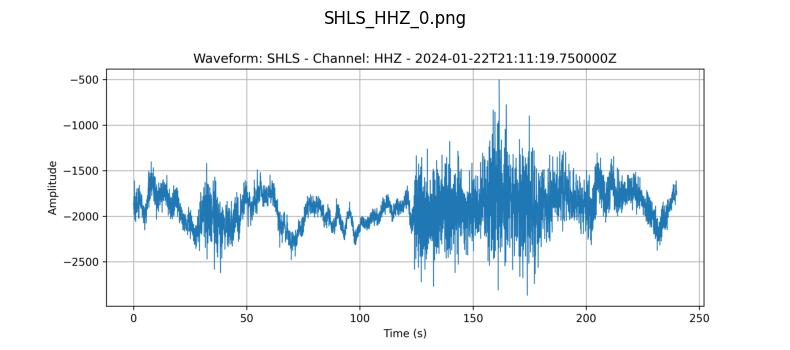

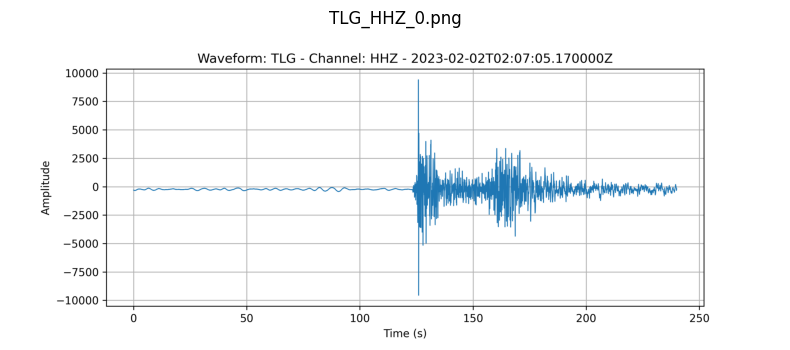

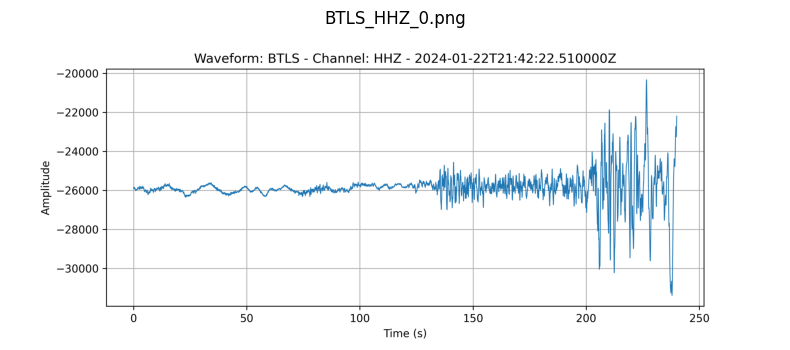

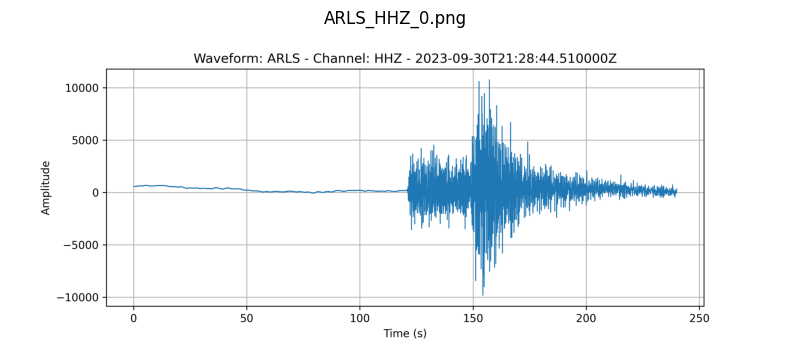

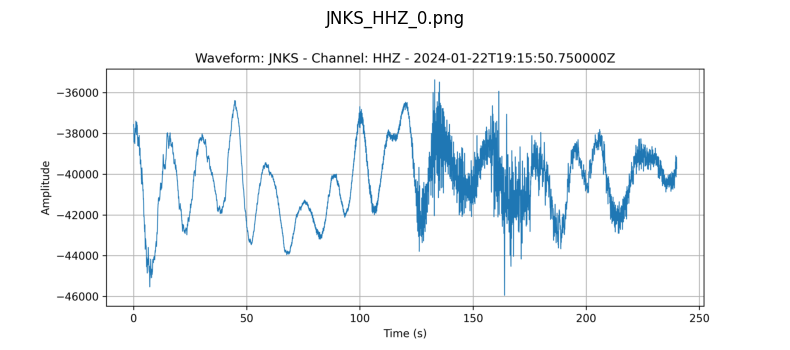

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# مسار مجلد الصور
image_folder = "images_train"

# قائمة الصور في المجلد
image_files = [f for f in os.listdir(image_folder) if f.endswith(".png")]

# عرض أول 5 صور مثلاً
for image_name in image_files[:5]:
    image_path = os.path.join(image_folder, image_name)
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(image_name)
    plt.show()


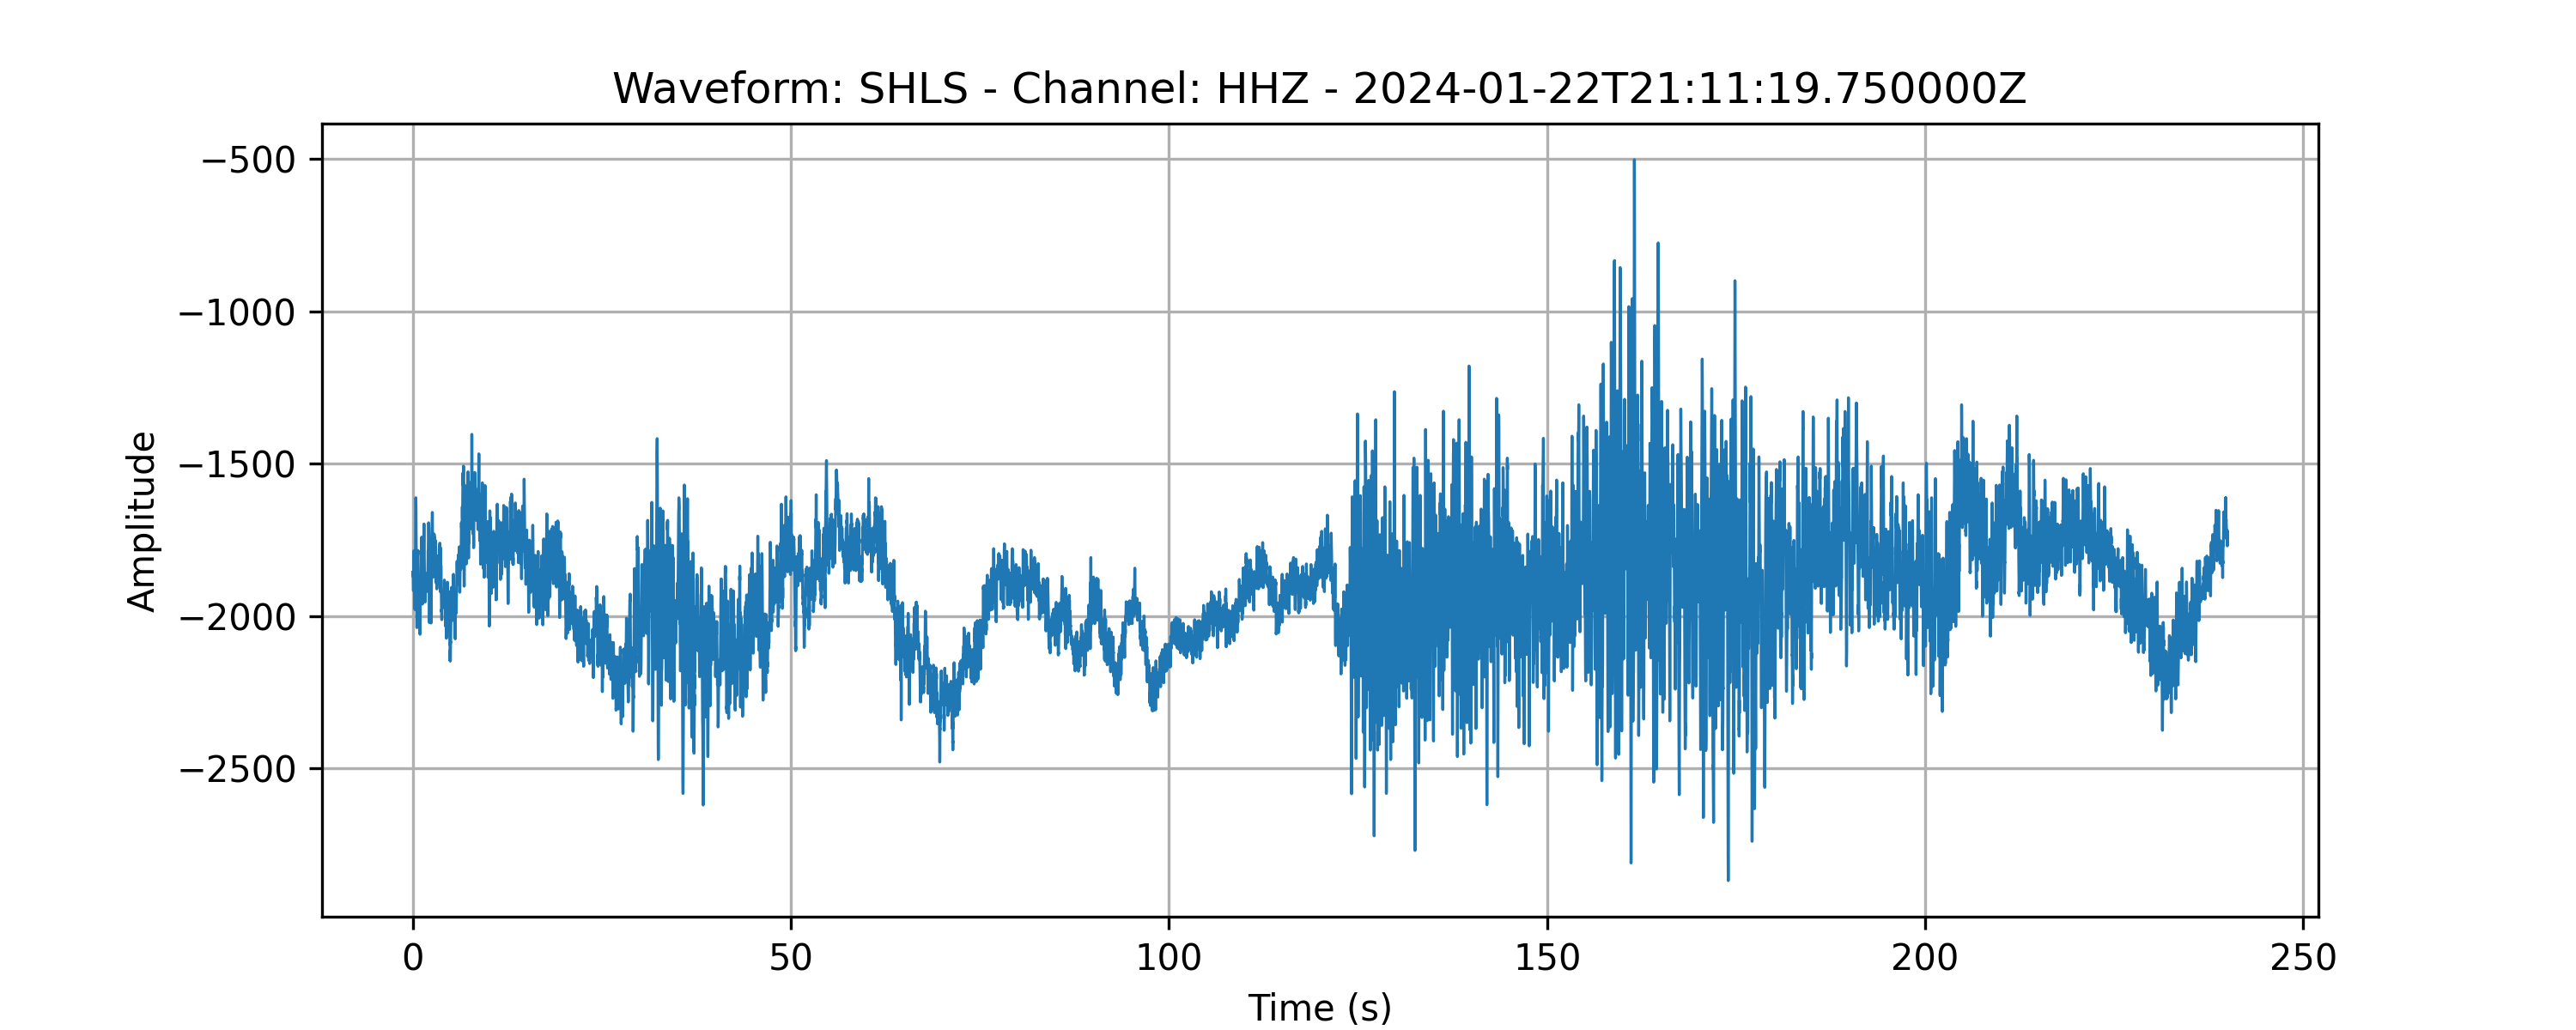

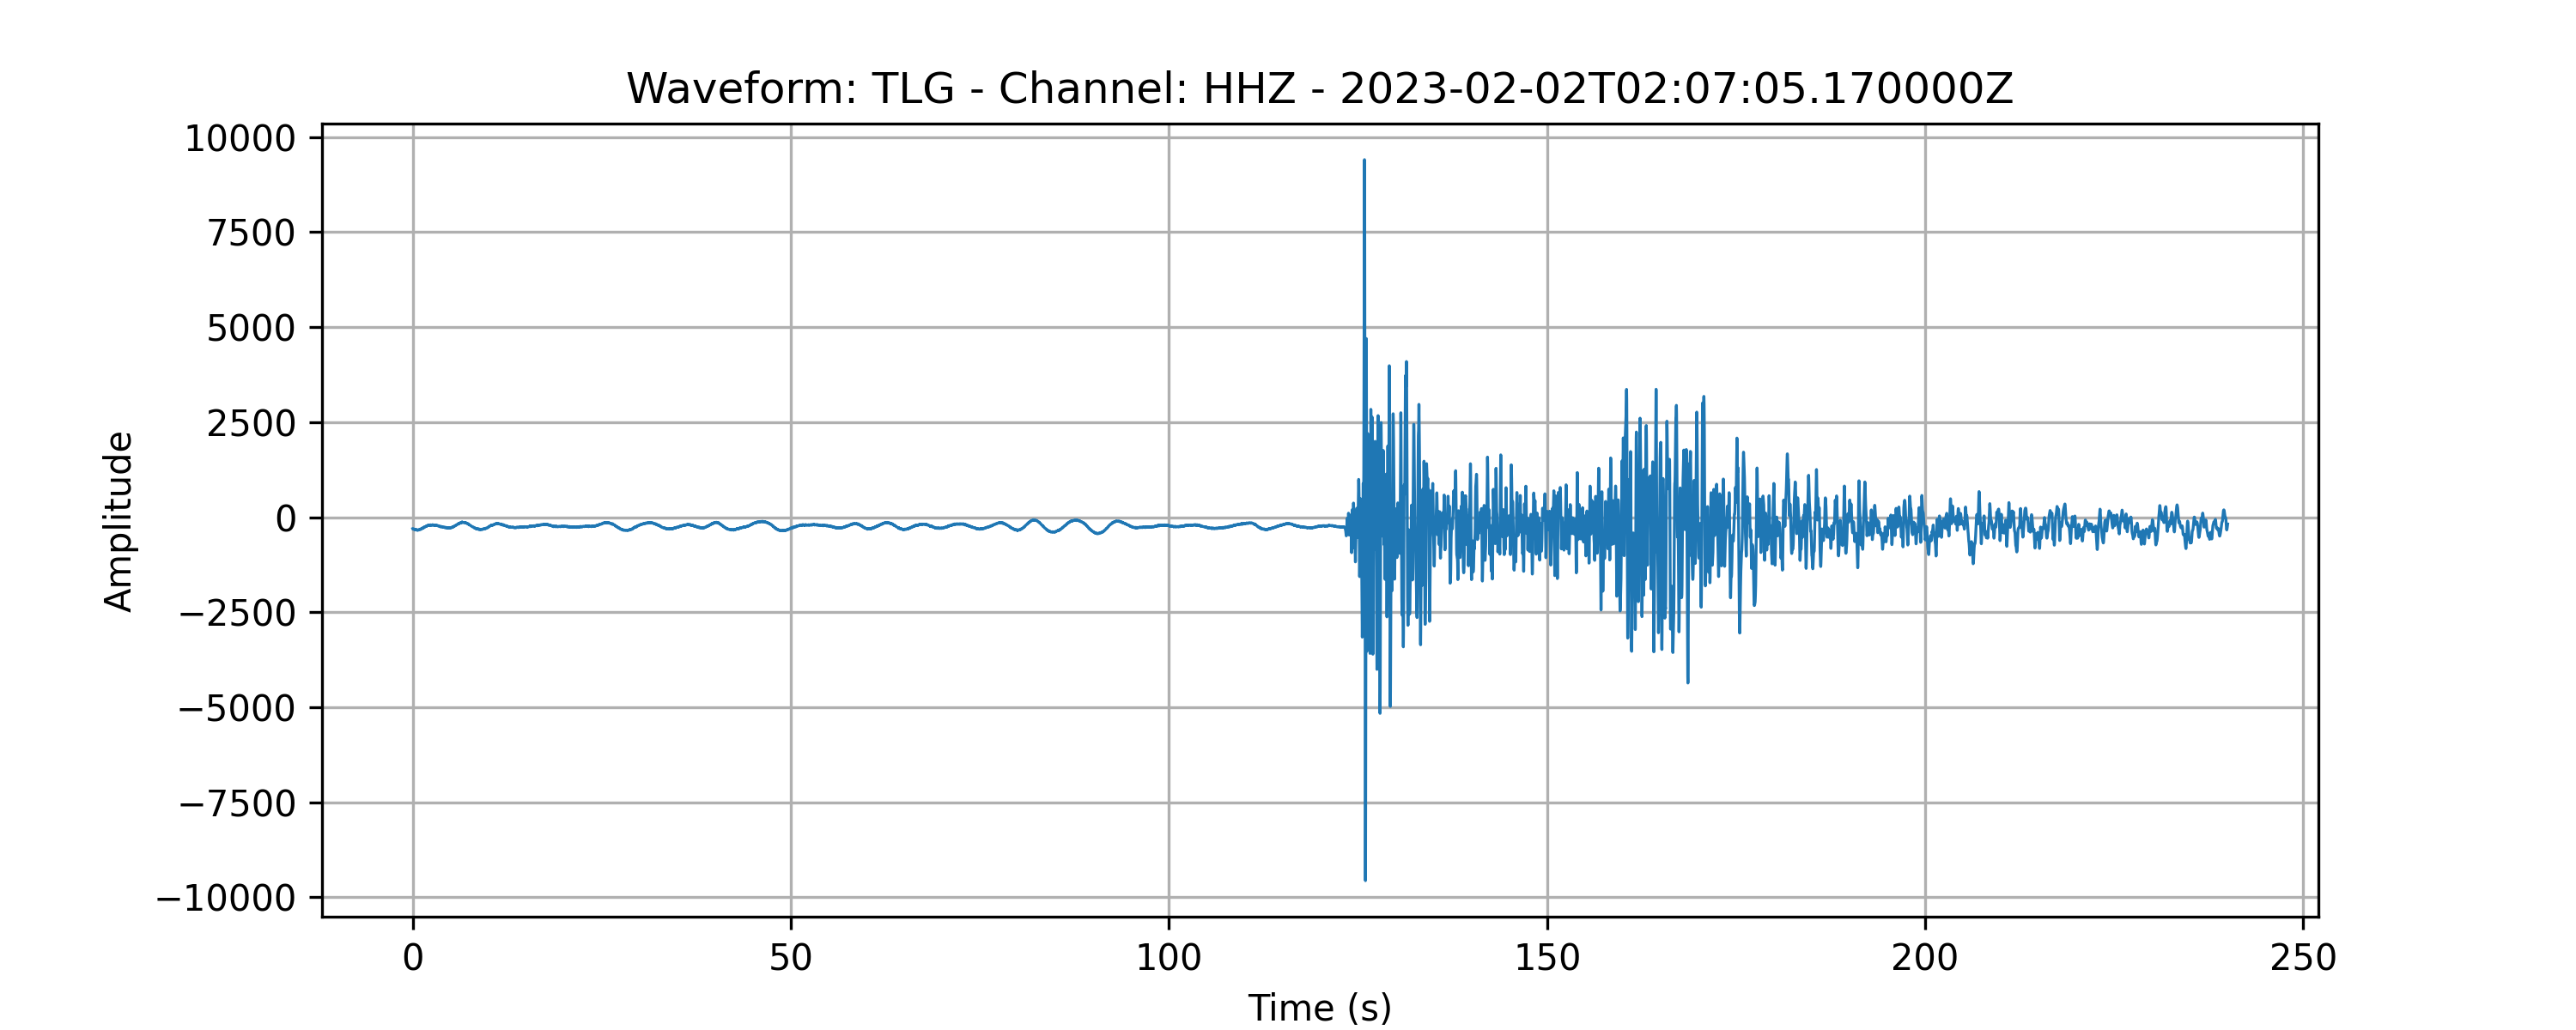

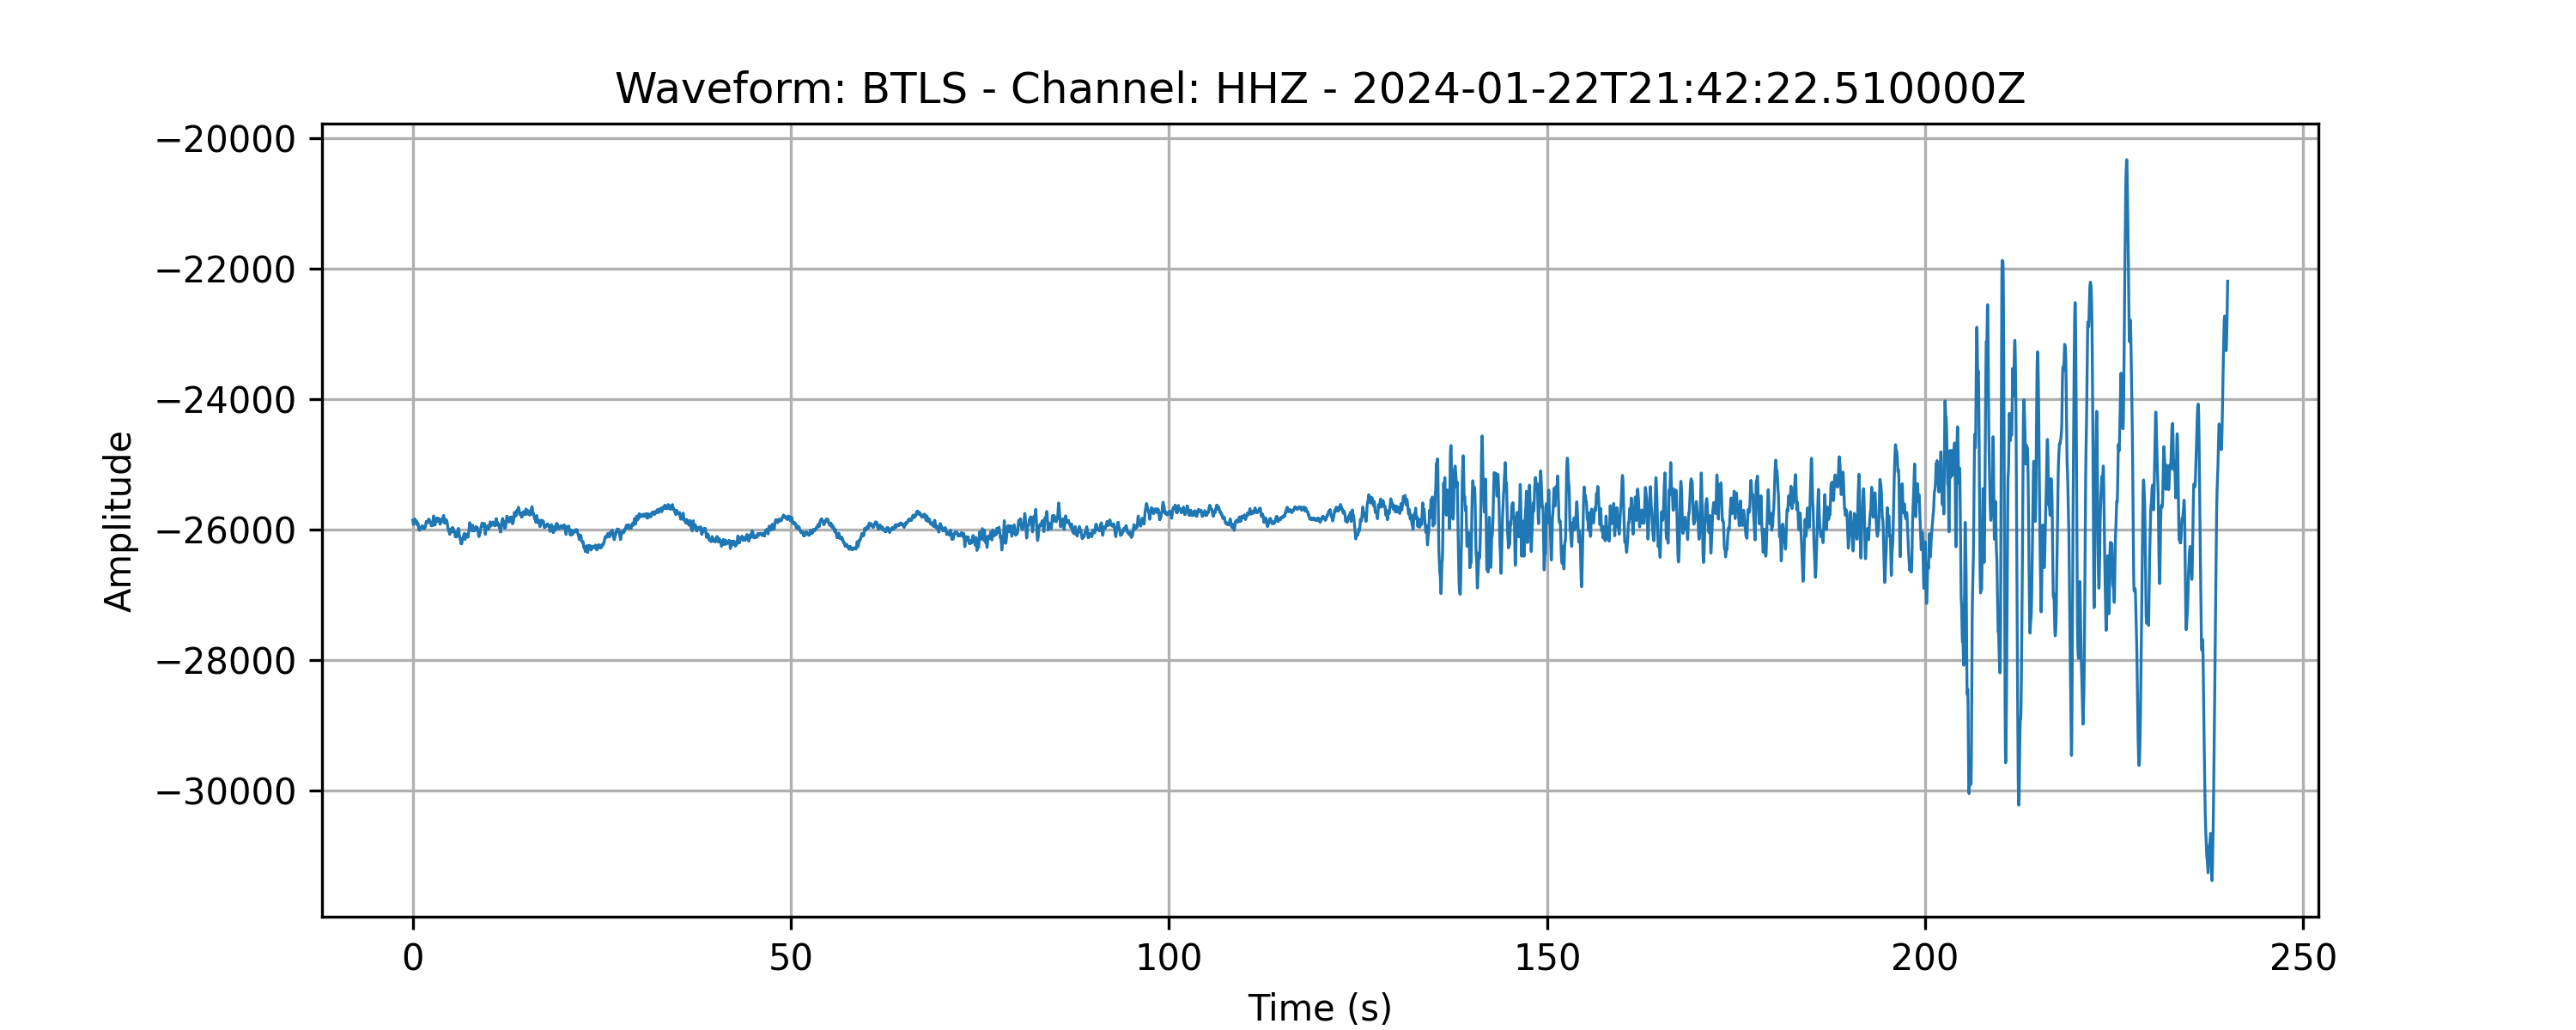

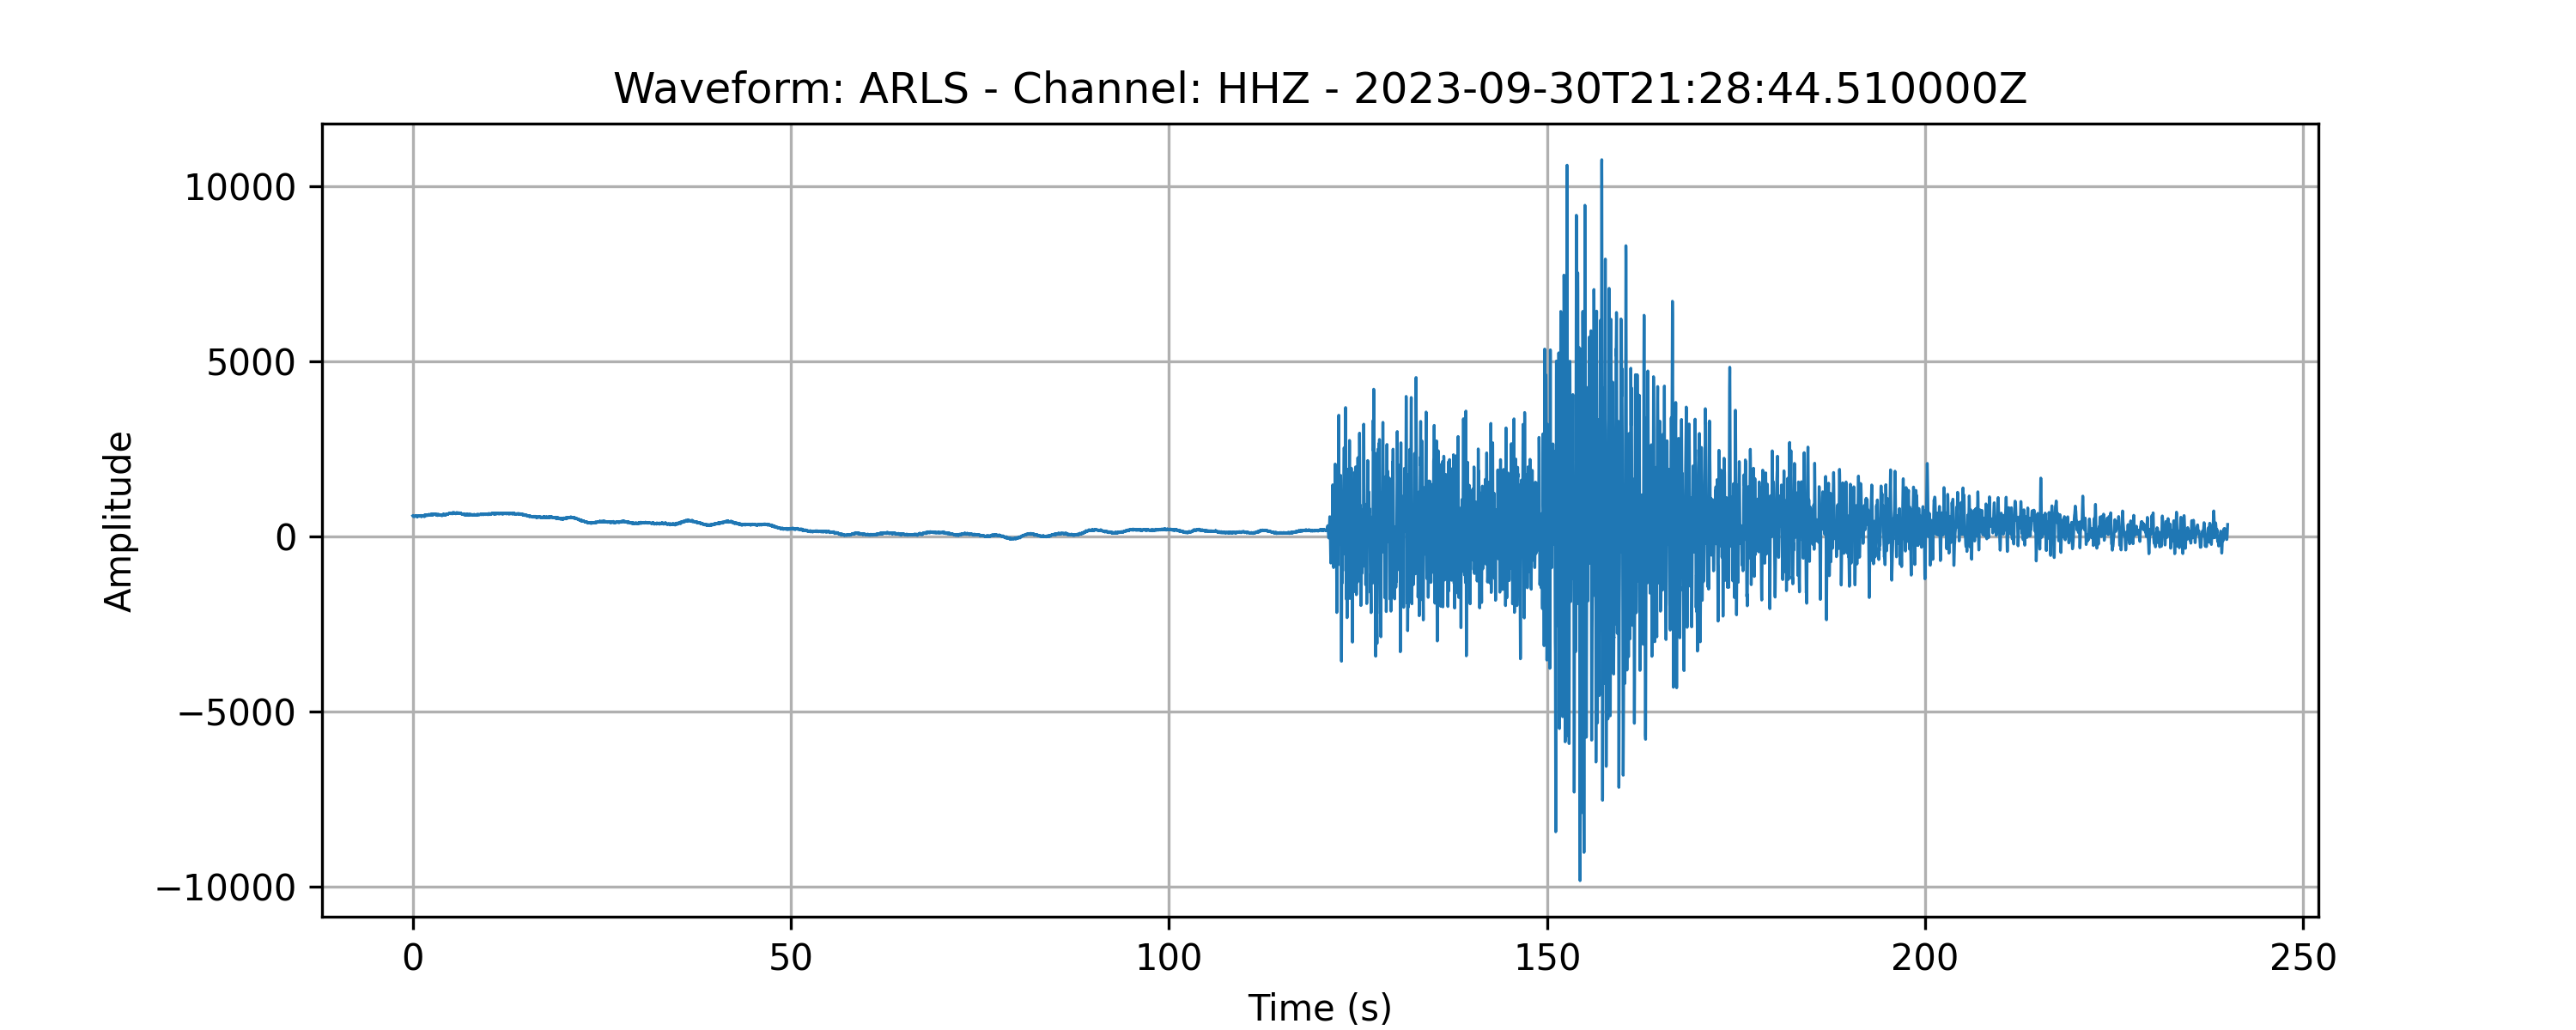

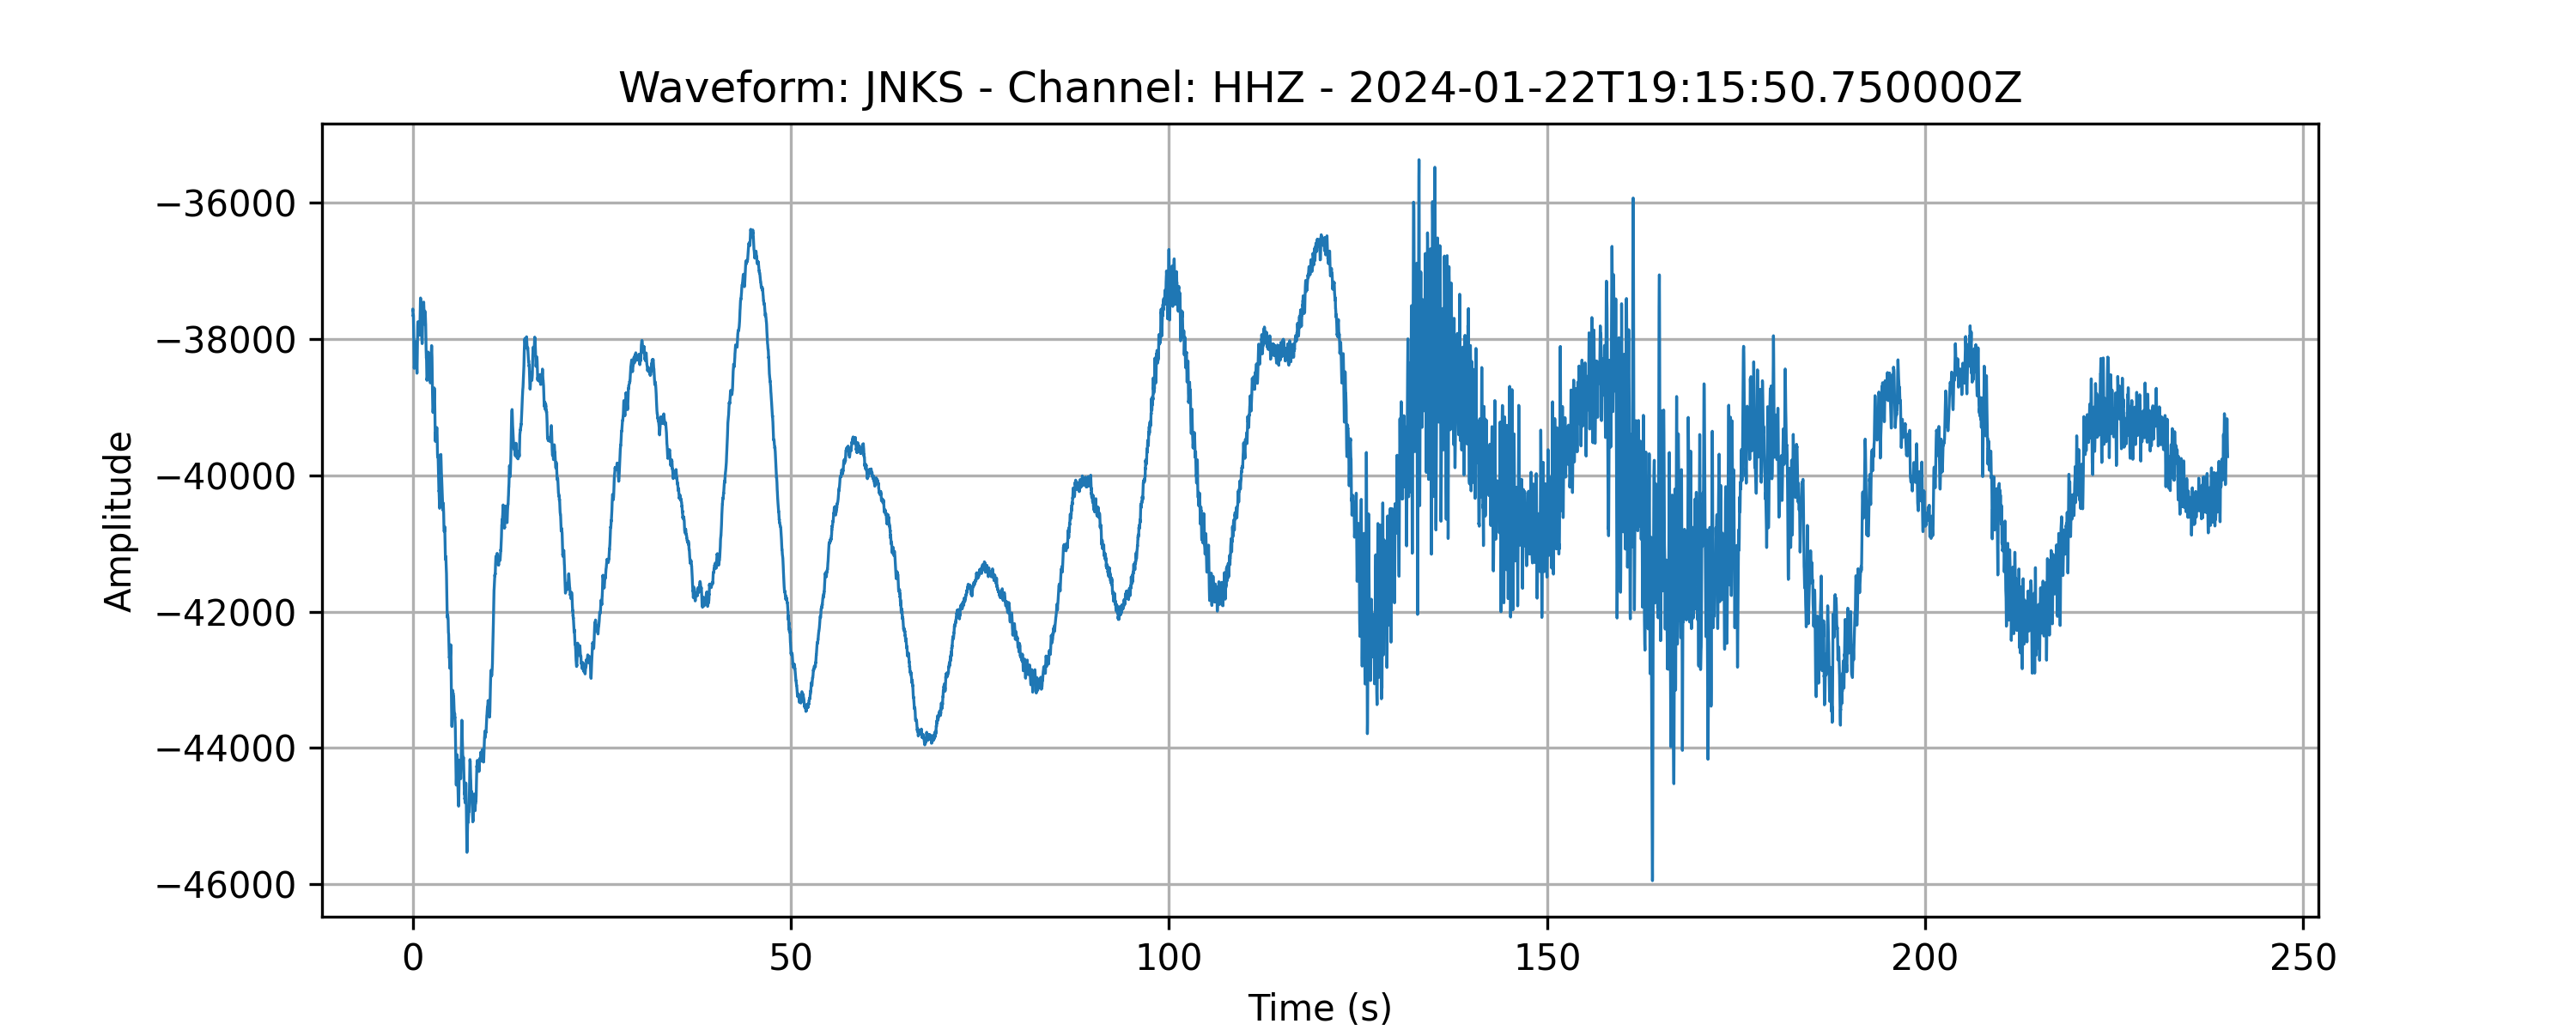

In [ ]:
from IPython.display import Image, display

image_folder = "images_train"
image_files = [f for f in os.listdir(image_folder) if f.endswith(".png")]

# عرض أول 5 صور كمصغرات
for image_name in image_files[:5]:
    display(Image(filename=os.path.join(image_folder, image_name)))


#Time Domain Features

In [ ]:
import os
import numpy as np
import pandas as pd
from obspy import read
from scipy.stats import kurtosis, skew
from scipy.signal import hilbert, welch
from scipy.fftpack import fft

def extract_features(trace):
    data = trace.data.astype(np.float32)
    n = len(data)
    sampling_rate = trace.stats.sampling_rate

    # إحصائية
    mean = np.mean(data)
    std = np.std(data)
    var = np.var(data)
    max_val = np.max(data)
    min_val = np.min(data)
    skewness = skew(data)
    kurt = kurtosis(data)
    rms = np.sqrt(np.mean(data**2))
    abs_max = np.max(np.abs(data))
    p25 = np.percentile(data, 25)
    p50 = np.percentile(data, 50)
    p75 = np.percentile(data, 75)

    # طاقة
    energy = np.sum(data**2)

    # Zero Crossing Rate
    zcr = ((data[:-1] * data[1:]) < 0).sum() / n

    # PGA و PGV
    pga = abs_max
    velocity = np.cumsum(data) / sampling_rate
    pgv = np.max(np.abs(velocity))

    # المظروف (envelope)
    envelope = np.abs(hilbert(data))
    rise_time = np.argmax(envelope) / sampling_rate
    duration = len(data) / sampling_rate

    # FFT
    freqs, psd = welch(data, fs=sampling_rate)
    spectral_centroid = np.sum(freqs * psd) / np.sum(psd)
    bandwidth = np.sqrt(np.sum(((freqs - spectral_centroid) ** 2) * psd) / np.sum(psd))
    spectral_entropy = -np.sum(psd * np.log(psd + 1e-12)) / np.log(len(psd))
    flatness = np.exp(np.mean(np.log(psd + 1e-12))) / (np.mean(psd) + 1e-12)
    roll_off = freqs[np.where(np.cumsum(psd) >= 0.85 * np.sum(psd))[0][0]]
    dominant_freq = freqs[np.argmax(psd)]

    return {
        'mean': mean,
        'std': std,
        'var': var,
        'max': max_val,
        'min': min_val,
        'skewness': skewness,
        'kurtosis': kurt,
        'rms': rms,
        'abs_max': abs_max,
        'p25': p25,
        'p50': p50,
        'p75': p75,
        'energy': energy,
        'zcr': zcr,
        'pga': pga,
        'pgv': pgv,
        'rise_time': rise_time,
        'duration': duration,
        'spectral_centroid': spectral_centroid,
        'bandwidth': bandwidth,
        'spectral_entropy': spectral_entropy,
        'spectral_flatness': flatness,
        'roll_off': roll_off,
        'dominant_freq': dominant_freq
    }

# المسار إلى الملفات
folder_path = "/content/drive/MyDrive/Data/train"
features_list = []

for file in os.listdir(folder_path):
    if file.endswith(".mseed"):
        st = read(os.path.join(folder_path, file))
        for tr in st:
            feats = extract_features(tr)
            feats["filename"] = file
            features_list.append(feats)

# حفظ النتائج
df = pd.DataFrame(features_list)
df.to_csv("/content/drive/MyDrive/Data/earthquake_features_all.csv", index=False)
print("✅ Extraction done. Features saved to earthquake_features_all.csv")


In [ ]:
import pandas as pd

# تحميل الملف
df = pd.read_csv('/content/drive/MyDrive/Data/earthquake_features_all.csv')

# عرض أول 10 صفوف
print(df.head(10))


In [ ]:
import os
import numpy as np
import pandas as pd
from obspy import read
import pywt
from scipy.signal import stft
from scipy.stats import entropy

def extract_wavelet_features(signal, wavelet='db4', level=5):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    features = {}
    for i, c in enumerate(coeffs):
        features[f'wavelet_L{i}_mean'] = np.mean(c)
        features[f'wavelet_L{i}_std'] = np.std(c)
        features[f'wavelet_L{i}_energy'] = np.sum(np.square(c))
        features[f'wavelet_L{i}_entropy'] = entropy(np.abs(c) / np.sum(np.abs(c)) + 1e-8)
    return features

def extract_stft_features(signal, fs):
    f, t, Zxx = stft(signal, fs=fs, nperseg=256)
    power = np.abs(Zxx) ** 2
    total_power = np.sum(power)
    dominant_freqs = f[np.argmax(power, axis=0)]
    avg_dominant_freq = np.mean(dominant_freqs)
    spectral_entropy = entropy(np.mean(power, axis=1) + 1e-8)

    features = {
        'stft_total_power': total_power,
        'stft_avg_dominant_freq': avg_dominant_freq,
        'stft_spectral_entropy': spectral_entropy
    }
    return features

def extract_all_features(file_path):
    try:
        st = read(file_path)
        tr = st[0]
        data = tr.data.astype(np.float64)
        fs = tr.stats.sampling_rate

        wavelet_feats = extract_wavelet_features(data)
        stft_feats = extract_stft_features(data, fs)

        all_features = {**wavelet_feats, **stft_feats}
        all_features['filename'] = os.path.basename(file_path)
        return all_features
    except Exception as e:
        print(f"Error in {file_path}: {e}")
        return None

# === تطبيق على مجلد كامل ===
folder_path = "/content/drive/MyDrive/Data/train"
features_list = []

for filename in os.listdir(folder_path):
    if filename.endswith(".mseed"):
        file_path = os.path.join(folder_path, filename)
        feats = extract_all_features(file_path)
        if feats:
            features_list.append(feats)

# حفظ النتائج في ملف CSV
df = pd.DataFrame(features_list)
df.to_csv("/content/drive/MyDrive/Data/wavelet_stft_features.csv", index=False)
print("✅ Feature extraction complete and saved.")


In [ ]:
import pandas as pd

# تحميل الملف
df = pd.read_csv('/content/drive/MyDrive/Data/wavelet_stft_features.csv')

# عرض أول 10 صفوف
print(df.head(10))

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
from obspy import read

# مسار مجلد البيانات
data_path = "/content/drive/MyDrive/Data/train"

# عدد معاملات MFCC المطلوبة
n_mfcc = 13

# دالة لتحويل ملف mseed إلى MFCC
def extract_mfcc_from_mseed(file_path, n_mfcc=13):
    try:
        # قراءة البيانات
        stream = read(file_path)
        tr = stream[0]  # نفترض وجود قناة واحدة فقط
        y = tr.data.astype(np.float32)
        sr = tr.stats.sampling_rate

        # استخراج MFCC
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfccs_mean = np.mean(mfccs, axis=1)  # أخذ المتوسط لكل معامل
        return mfccs_mean
    except Exception as e:
        print(f"Error with file {file_path}: {e}")
        return None

# تجهيز قائمة المميزات
features_list = []
file_names = []

# المرور على كل الملفات في المجلد
for filename in os.listdir(data_path):
    if filename.endswith(".mseed"):
        file_path = os.path.join(data_path, filename)
        mfcc_features = extract_mfcc_from_mseed(file_path, n_mfcc=n_mfcc)
        if mfcc_features is not None:
            features_list.append(mfcc_features)
            file_names.append(filename)

# تحويل النتائج إلى DataFrame
df = pd.DataFrame(features_list, columns=[f"mfcc_{i+1}" for i in range(n_mfcc)])
df["filename"] = file_names

# حفظ النتائج
df.to_csv("/content/drive/MyDrive/Data/mfcc_features.csv", index=False)
print("✅ تم استخراج المميزات وحفظها في mfcc_features.csv")


In [ ]:
import pandas as pd

# تحميل الملف
df = pd.read_csv('/content/drive/MyDrive/Data/mfcc_features.csv')

# عرض أول 10 صفوف
print(df.head(10))


In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
from scipy.stats import skew, kurtosis
from tqdm import tqdm

# 🟡 دالة استخراج جميع الميزات من MFCC
def extract_mfcc_features(file_path, n_mfcc=13):
    try:
        y, sr = librosa.load(file_path, sr=None)

        # MFCCs
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

        # المشتقة الأولى والثانية
        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)

        # الطاقة
        energy = np.sum(mfcc ** 2, axis=1)
        log_energy = np.log(np.sum(mfcc ** 2, axis=1) + 1e-8)

        features = {}

        # نضيف الإحصائيات لكل MFCC
        for i in range(n_mfcc):
            coeff = mfcc[i]
            features[f'mfcc_{i+1}_mean'] = np.mean(coeff)
            features[f'mfcc_{i+1}_std'] = np.std(coeff)
            features[f'mfcc_{i+1}_min'] = np.min(coeff)
            features[f'mfcc_{i+1}_max'] = np.max(coeff)
            features[f'mfcc_{i+1}_median'] = np.median(coeff)
            features[f'mfcc_{i+1}_skew'] = skew(coeff)
            features[f'mfcc_{i+1}_kurtosis'] = kurtosis(coeff)

            # مشتقة أولى وثانية
            features[f'delta_{i+1}_mean'] = np.mean(delta[i])
            features[f'delta2_{i+1}_mean'] = np.mean(delta2[i])

        # الطاقة
        features['energy_mean'] = np.mean(energy)
        features['energy_std'] = np.std(energy)
        features['log_energy_mean'] = np.mean(log_energy)
        features['log_energy_std'] = np.std(log_energy)

        return features
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# 🟡 المسار إلى ملفات الزلازل بصيغة WAV
folder_path = '/content/drive/MyDrive/Data/train'

# 🟡 استخراج الميزات من جميع الملفات
all_features = []
file_names = []

for filename in tqdm(os.listdir(folder_path)):
    if filename.endswith('.wav'):
        file_path = os.path.join(folder_path, filename)
        features = extract_mfcc_features(file_path)
        if features:
            features['file_name'] = filename
            all_features.append(features)

# 🟡 تحويل إلى DataFrame وتصديره
output_csv = "/content/drive/MyDrive/Data/earthquake_mfcc_full_features.csv"
df.to_csv(output_csv, index=False)
print(f"\n✅ Features extracted and saved to: {output_csv}")

# عرض أول 10 صفوف
print(df.head(10))

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm
from obspy import read
import warnings
warnings.filterwarnings("ignore")

# مسار مجلد البيانات
DATA_PATH = "/content/drive/MyDrive/Data/train"

# دالة لتحويل mseed إلى إشارة صوتية قابلة للمعالجة
def load_mseed_audio(file_path):
    try:
        st = read(file_path)
        tr = st[0]
        y = tr.data.astype(np.float32)
        sr = tr.stats.sampling_rate
        return y, sr
    except Exception as e:
        print(f"❌ Error reading {file_path}: {e}")
        return None, None

# دالة استخراج كل المميزات الصوتية
def extract_all_features(file_path):
    y, sr = load_mseed_audio(file_path)
    if y is None or len(y) < 100:
        return None

    features = {}

    # MFCCs
    try:
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        for i in range(mfccs.shape[0]):
            features[f'mfcc{i+1}_mean'] = np.mean(mfccs[i])
            features[f'mfcc{i+1}_std'] = np.std(mfccs[i])
            features[f'mfcc{i+1}_max'] = np.max(mfccs[i])
            features[f'mfcc{i+1}_min'] = np.min(mfccs[i])
    except:
        pass

    # Chroma
    try:
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        for i in range(chroma.shape[0]):
            features[f'chroma{i+1}_mean'] = np.mean(chroma[i])
            features[f'chroma{i+1}_std'] = np.std(chroma[i])
    except:
        pass

    # Spectral Contrast (ضبط تلقائي للنطاقات لتجنب تجاوز Nyquist)
    try:
        nyquist = sr / 2
        fmin = max(20.0, sr / 512)
        n_bands = 6
        while fmin * (2 ** n_bands) >= nyquist and n_bands > 1:
            n_bands -= 1
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr, fmin=fmin, n_bands=n_bands)
        for i in range(contrast.shape[0]):
            features[f'contrast{i+1}_mean'] = np.mean(contrast[i])
            features[f'contrast{i+1}_std'] = np.std(contrast[i])
    except Exception as e:
        print(f"⚠️ Skipping spectral_contrast for {os.path.basename(file_path)}: {e}")

    # Tonnetz
    try:
        tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr)
        for i in range(tonnetz.shape[0]):
            features[f'tonnetz{i+1}_mean'] = np.mean(tonnetz[i])
            features[f'tonnetz{i+1}_std'] = np.std(tonnetz[i])
    except:
        pass

    # Zero Crossing Rate
    try:
        zcr = librosa.feature.zero_crossing_rate(y)
        features['zcr_mean'] = np.mean(zcr)
        features['zcr_std'] = np.std(zcr)
    except:
        pass

    # Spectral Centroid
    try:
        centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        features['centroid_mean'] = np.mean(centroid)
    except:
        pass

    # Spectral Bandwidth
    try:
        bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        features['bandwidth_mean'] = np.mean(bandwidth)
    except:
        pass

    # Spectral Rolloff
    try:
        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        features['rolloff_mean'] = np.mean(rolloff)
    except:
        pass

    # Root Mean Square Energy
    try:
        rmse = librosa.feature.rms(y=y)
        features['rmse_mean'] = np.mean(rmse)
    except:
        pass

    # Tempo
    try:
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        features['tempo'] = tempo
    except:
        features['tempo'] = 0.0

    return features

# تجميع كل المميزات
data = []
print("🚀 بدء استخراج المميزات من الملفات:")

for filename in tqdm(os.listdir(DATA_PATH)):
    if filename.endswith(".mseed"):
        file_path = os.path.join(DATA_PATH, filename)
        feats = extract_all_features(file_path)
        if feats:
            feats['filename'] = filename
            data.append(feats)

# تحويل النتائج إلى DataFrame
df = pd.DataFrame(data)

# حفظ النتائج
output_csv = "/content/drive/MyDrive/Data/#earthquake_features_full.csv"
df.to_csv(output_csv, index=False)
print(f"\n✅ Features extracted and saved to: {output_csv}")

# عرض أول 10 صفوف
print(df.head(10))


In [ ]:
import pandas as pd

# قائمة بكل الملفات
file_paths = [
    "/content/drive/MyDrive/Data/earthquake_features_full.csv",
    "/content/drive/MyDrive/Data/earthquake_features_all.csv",
    "/content/drive/MyDrive/Data/earthquake_mfcc_full_features.csv",
    "/content/drive/MyDrive/Data/mfcc_features.csv",
    "/content/drive/MyDrive/Data/wavelet_stft_features.csv"
]

# تحميل ودمج كل البيانات
all_dataframes = []

for file in file_paths:
    try:
        df = pd.read_csv(file)
        all_dataframes.append(df)
    except Exception as e:
        print(f"خطأ في قراءة الملف {file}: {e}")

# دمج كل الـ DataFrames في واحد
combined_df = pd.concat(all_dataframes, ignore_index=True)

# حذف الصفوف المتكررة تمامًا
combined_df.drop_duplicates(inplace=True)

# حفظ الملف النهائي
output_path = "/content/drive/MyDrive/Data/merged_unique_features.csv"
combined_df.to_csv(output_path, index=False)

# عرض الإحصائيات
print(f"✅ تم الدمج بنجاح وحفظ الملف في: {output_path}")
print(f"📊 عدد الصفوف بعد الدمج وإزالة التكرار: {len(combined_df)}")

# عرض أول 10 صفوف
print(combined_df.head(10))


In [ ]:
import pandas as pd

# تحميل الملف الأصلي
df = pd.read_csv("/content/drive/MyDrive/Data/merged_unique_features.csv")

# حذف الأعمدة التي تحتوي على أكثر من 50% قيم NaN
threshold = len(df) * 0.5
df = df.dropna(axis=1, thresh=threshold)

# حذف الصفوف المتبقية التي ما زال بها NaN
df_cleaned = df.dropna()

# حفظ الملف النهائي
cleaned_path = "/content/drive/MyDrive/Data/final_cleaned_features.csv"
df_cleaned.to_csv(cleaned_path, index=False)

# عرض أول 10 صفوف
print(df_cleaned.head(10))


#labels

In [ ]:
import os
import obspy
import numpy as np
import pandas as pd
from obspy.signal.trigger import classic_sta_lta, trigger_onset

# مسار الملفات
data_path = "/content/drive/MyDrive/Data/train"
file_list = [os.path.join(data_path, f) for f in os.listdir(data_path) if f.endswith(".mseed")]

# قائمة للنتائج
data_records = []

# إعدادات الـ STA/LTA
sta = 1  # short-term average window (ثواني)
lta = 10  # long-term average window (ثواني)
trigger_on = 2.5
trigger_off = 0.5

# تحليل كل ملف
for file in file_list:
    try:
        # قراءة الملف
        st = obspy.read(file)
        tr = st[0]  # نستخدم أول قناة

        # التأكد من التردد
        tr.detrend("demean")
        df = tr.stats.sampling_rate
        cft = classic_sta_lta(tr.data, int(sta * df), int(lta * df))

        # تحديد نقاط البداية والانتهاء لـ P-wave
        on_off = trigger_onset(cft, trigger_on, trigger_off)

        # إذا تم الكشف عن زلزال
        if len(on_off) > 0:
            label = 1
        else:
            label = 0

        # استخراج بعض المميزات البسيطة (يمكنك تعديلها لاحقًا)
        features = {
            "mean": np.mean(tr.data),
            "std": np.std(tr.data),
            "max": np.max(tr.data),
            "min": np.min(tr.data),
            "label": label,
            "filename": os.path.basename(file)
        }

        data_records.append(features)

    except Exception as e:
        print(f"Error in {file}: {e}")

# تحويل النتائج إلى DataFrame
df = pd.DataFrame(data_records)

# حفظ الملف النهائي
df.to_csv("/content/drive/MyDrive/Data/earthquake_features_labeled.csv", index=False)
print("✅ تم إنشاء ملف features مع التصنيفات Label.")


In [ ]:
import os
import numpy as np
import pandas as pd
from obspy import read
from tqdm import tqdm

# مسار مجلد البيانات الزلزالية
MSEED_DIR = "/content/drive/MyDrive/Data/train"

# تحديد العتبة لتوليد الـ label (يمكن تعديلها حسب تحليل البيانات)
RMS_THRESHOLD = 1000

# إنشاء قائمة لتخزين جميع الخصائص
features = []

# استعراض جميع ملفات .mseed داخل المجلد
for filename in tqdm(os.listdir(MSEED_DIR), desc="Processing MSEED Files"):
    if not filename.endswith(".mseed"):
        continue

    file_path = os.path.join(MSEED_DIR, filename)

    try:
        # قراءة الملف
        stream = read(file_path)

        # التعامل مع كل trace في الملف
        for tr in stream:
            signal = tr.data.astype(np.float32)

            # حساب الخصائص الإحصائية
            mean_amp = np.mean(np.abs(signal))
            std_amp  = np.std(signal)
            max_amp  = np.max(np.abs(signal))
            rms_amp  = np.sqrt(np.mean(signal ** 2))

            # توليد label اعتمادًا على عتبة RMS
            label = 1 if rms_amp > RMS_THRESHOLD else 0

            # إضافة الخصائص إلى القائمة
            features.append({
                "file": filename,
                "station": tr.stats.station,
                "channel": tr.stats.channel,
                "starttime": str(tr.stats.starttime),
                "mean_amp": mean_amp,
                "std_amp": std_amp,
                "max_amp": max_amp,
                "rms_amp": rms_amp,
                "label": label
            })

    except Exception as e:
        print(f"❌ Error processing {filename}: {e}")

# تحويل القائمة إلى DataFrame
df = pd.DataFrame(features)

# حفظ الملف النهائي بصيغة CSV
output_path = "/content/drive/MyDrive/Data/labeled_features.csv"
df.to_csv(output_path, index=False)

print(f"\n✅ Done! Labeled features saved to: {output_path}")


Processing MSEED Files: 100%|██████████| 935/935 [00:19<00:00, 48.49it/s]


✅ Done! Labeled features saved to: /content/drive/MyDrive/Data/labeled_features.csv


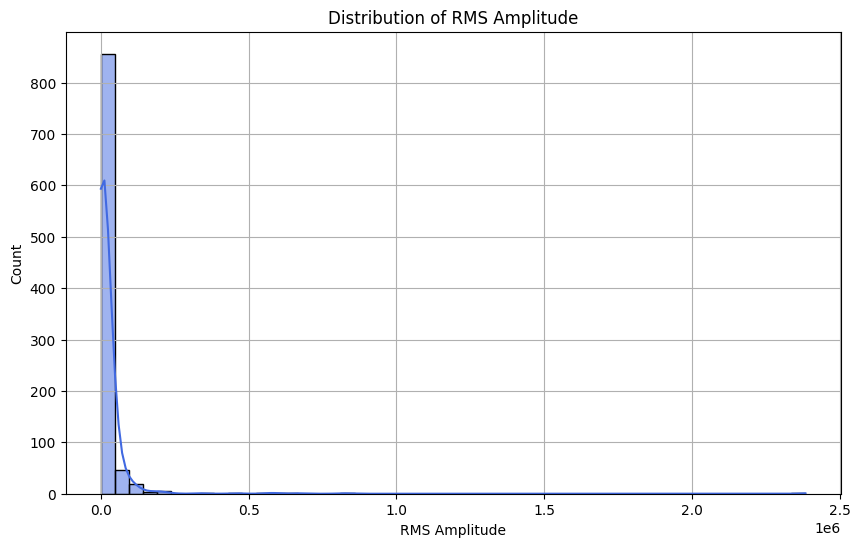

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# قراءة البيانات المولدة سابقًا
df = pd.read_csv('/content/drive/MyDrive/Data/labeled_features.csv')

# رسم التوزيع
plt.figure(figsize=(10, 6))
sns.histplot(df["rms_amp"], bins=50, kde=True, color='royalblue')
plt.title("Distribution of RMS Amplitude")
plt.xlabel("RMS Amplitude")
plt.ylabel("Count")
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd

# تحميل البيانات التي استخرجت سابقًا
df = pd.read_csv('/content/drive/MyDrive/Data/labeled_features.csv')

# حساب العتبة بناءً على النسبة المئوية (مثلاً: أعلى 10%)
threshold = df['rms_amp'].quantile(0.90)

print(f"🔍 RMS threshold based on 90th percentile = {threshold:.2f}")



🔍 RMS threshold based on 90th percentile = 44392.19


In [ ]:
import pandas as pd

# 1. تحميل الملف المولد مسبقًا
df = pd.read_csv('/content/drive/MyDrive/Data/labeled_features.csv')

# 2. تطبيق العتبة الذكية بناءً على الـ 90th percentile
RMS_THRESHOLD = 44392.19  # بناءً على التحليل الذكي

# 3. إنشاء عمود label جديد اعتمادًا على العتبة
df['label'] = df['rms_amp'].apply(lambda x: 1 if x > RMS_THRESHOLD else 0)

# 4. حفظ الملف الجديد بتسمية واضحة
output_path = '/content/drive/MyDrive/Data/labeled_features_balanced.csv'
df.to_csv(output_path, index=False)

# 5. عرض إحصائيات سريعة
print("✅ تم إنشاء التصنيفات بناءً على العتبة الذكية:")
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True).apply(lambda x: f"{x:.2%}"))


✅ تم إنشاء التصنيفات بناءً على العتبة الذكية:
label
0    841
1     94
Name: count, dtype: int64
label
0    89.95%
1    10.05%
Name: proportion, dtype: object


In [ ]:
from obspy import read
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

# مسار بيانات test
test_dir = "/content/drive/MyDrive/Data/test"

# عتبة ذكية نفس train (حسب ما حسبناه سابقًا)
RMS_THRESHOLD = 44392.19

# تجميع الخصائص
test_features = []

for filename in tqdm(os.listdir(test_dir), desc="Processing test data"):
    if not filename.endswith(".mseed"):
        continue
    try:
        stream = read(os.path.join(test_dir, filename))
        for tr in stream:
            data = tr.data.astype(np.float32)

            mean_amp = np.mean(np.abs(data))
            std_amp  = np.std(data)
            max_amp  = np.max(np.abs(data))
            rms_amp  = np.sqrt(np.mean(data**2))

            label = 1 if rms_amp > RMS_THRESHOLD else 0

            test_features.append({
                "file": filename,
                "station": tr.stats.station,
                "channel": tr.stats.channel,
                "starttime": str(tr.stats.starttime),
                "mean_amp": mean_amp,
                "std_amp": std_amp,
                "max_amp": max_amp,
                "rms_amp": rms_amp,
                "label": label
            })
    except Exception as e:
        print(f"❌ Error in {filename}: {e}")

# تحويلها لملف CSV
df_test = pd.DataFrame(test_features)
df_test.to_csv('/content/drive/MyDrive/Data/labeled_test_features.csv', index=False)

print("✅ تم تصنيف بيانات test وحفظها بنجاح.")


In [ ]:
# تحميل البيانات
df_train = pd.read_csv('E:/master/Data/labeled_features_balanced.csv')
df_test  = pd.read_csv('E:/master/Data/testlabeled_test_features.csv')

# دمجهم
df_all = pd.concat([df_train, df_test], ignore_index=True)
df_all.to_csv('E:/master/Data/full_dataset.csv', index=False)

print("✅ تم دمج train و test في ملف موحد.")


✅ تم دمج train و test في ملف موحد.


In [ ]:
import pandas as pd

# قراءة الملفين
features_df = pd.read_csv(r'E:\master\Data\#earthquake_features_full.csv')
labels_df = pd.read_csv(r'E:\master\Data\full_dataset.csv')

# دمج الملفين باستخدام الأعمدة المناسبة
merged_df = pd.merge(features_df, labels_df, left_on='filename', right_on='file')

# حفظ الملف النهائي
merged_df.to_csv(r'E:\master\Data\merged_dataset.csv', index=False)

print("✅ تم الدمج بنجاح وحفظ الملف في: merged_dataset.csv")


✅ تم الدمج بنجاح وحفظ الملف في: merged_dataset.csv


التحميل ✅

المعالجة ✅

التقسيم ✅

التدريب ✅

التقييم ✅

الحفظ ✅

In [ ]:
df.head()


,mfcc1_mean,mfcc1_std,mfcc1_max,mfcc1_min,mfcc2_mean,mfcc2_std,mfcc2_max,mfcc2_min,mfcc3_mean,mfcc3_std,...,centroid_mean,bandwidth_mean,rolloff_mean,rmse_mean,tempo,mean_amp,std_amp,max_amp,rms_amp,label
0,820.93960,122.406555,1099.7106,709.24580,111.74356,91.579620,269.78482,13.233591,47.203186,37.575165,...,2.311520,4.014376,3.910406,3661.393,[inf],2893.9520,5577.3780,73217.0,5737.2495,0
1,850.47015,112.823890,1097.2670,686.88550,152.99630,65.223070,248.36984,44.229797,30.824585,37.786020,...,3.796999,5.782845,7.680560,2815.810,[inf],2357.3972,3440.8792,30980.0,3705.8767,0
2,890.52120,160.222400,1246.7877,747.91850,108.95020,92.605890,247.04776,7.831390,24.342243,37.776367,...,3.574265,5.526417,5.751330,4669.076,[inf],3487.4640,8215.7880,128761.0,8300.1550,0
3,848.21606,119.246826,1111.1119,724.31244,119.37454,85.087290,251.47731,12.549879,43.868420,36.787235,...,2.894107,4.981306,4.538938,3508.457,[inf],2861.0060,4861.1074,36243.0,5040.3037,0
4,943.66490,140.876700,1257.9733,816.64930,110.10901,92.194214,240.47818,6.131619,37.497665,38.638916,...,2.899522,4.508516,4.742562,8954.768,[inf],6656.1970,16040.2940,216931.0,16098.0670,0


In [ ]:
import pandas as pd
import numpy as np

# تحميل البيانات
df = pd.read_csv(r'E:\master\Data\merged_dataset.csv')

# تحويل '[inf]' و 'inf' و '-inf' إلى NaN
df.replace(['[inf]', 'inf', '-inf'], np.nan, inplace=True)

# تحويل كل الأعمدة القابلة للتحويل إلى أرقام
df = df.apply(pd.to_numeric, errors='ignore')

# حذف الصفوف التي تحتوي على قيم مفقودة (NaN)
df.dropna(inplace=True)


C:\Users\CM\AppData\Local\Temp\ipykernel_7320\3643039763.py:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


In [ ]:
# حذف الأعمدة غير المهمة
df = df.drop(columns=['filename', 'file', 'station', 'channel', 'starttime'], errors='ignore')

# فصل الميزات عن الهدف
X = df.drop(columns=['label'])
y = df['label']


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
import pandas as pd

# 1. تحميل الملف
df = pd.read_csv(r'E:\master\Data\merged_dataset.csv')

# 2. استبدال '[inf]' بالنُقصان (NaN)، ثم حذف الصفوف التي تحتوي على NaN
df.replace('[inf]', pd.NA, inplace=True)
df.dropna(inplace=True)

# 3. حفظ الملف النظيف في ملف جديد أو الكتابة فوق الملف القديم
df.to_csv(r'E:\master\Data\merged_dataset_cleaned.csv', index=False)

print("✅ تم حذف '[inf]' بنجاح وحفظ الملف النظيف.")


✅ تم حذف '[inf]' بنجاح وحفظ الملف النظيف.


In [ ]:
print(X.columns)
print(X.dtypes)


Index(['mfcc1_mean', 'mfcc1_std', 'mfcc1_max', 'mfcc1_min', 'mfcc2_mean',
       'mfcc2_std', 'mfcc2_max', 'mfcc2_min', 'mfcc3_mean', 'mfcc3_std',
       'mfcc3_max', 'mfcc3_min', 'mfcc4_mean', 'mfcc4_std', 'mfcc4_max',
       'mfcc4_min', 'mfcc5_mean', 'mfcc5_std', 'mfcc5_max', 'mfcc5_min',
       'mfcc6_mean', 'mfcc6_std', 'mfcc6_max', 'mfcc6_min', 'mfcc7_mean',
       'mfcc7_std', 'mfcc7_max', 'mfcc7_min', 'mfcc8_mean', 'mfcc8_std',
       'mfcc8_max', 'mfcc8_min', 'mfcc9_mean', 'mfcc9_std', 'mfcc9_max',
       'mfcc9_min', 'mfcc10_mean', 'mfcc10_std', 'mfcc10_max', 'mfcc10_min',
       'mfcc11_mean', 'mfcc11_std', 'mfcc11_max', 'mfcc11_min', 'mfcc12_mean',
       'mfcc12_std', 'mfcc12_max', 'mfcc12_min', 'mfcc13_mean', 'mfcc13_std',
       'mfcc13_max', 'mfcc13_min', 'chroma1_mean', 'chroma1_std',
       'chroma2_mean', 'chroma2_std', 'chroma3_mean', 'chroma3_std',
       'chroma4_mean', 'chroma4_std', 'chroma5_mean', 'chroma5_std',
       'chroma6_mean', 'chroma6_std', 'chroma7_me

📊 توزيع الفئات في بيانات التدريب:
 label
0    139
1     26
Name: count, dtype: int64


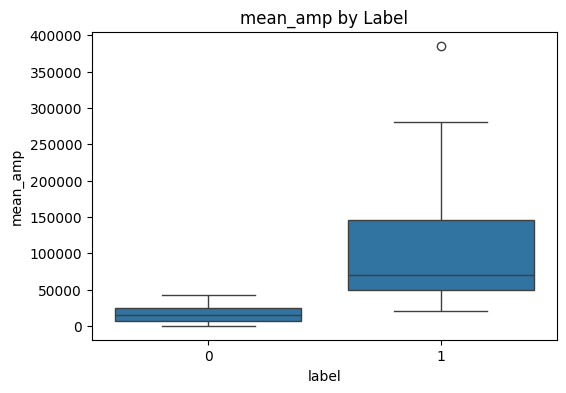

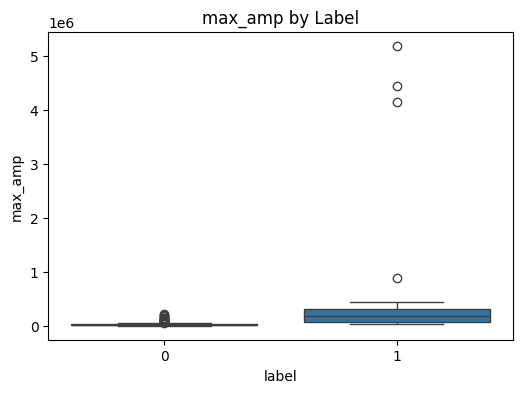

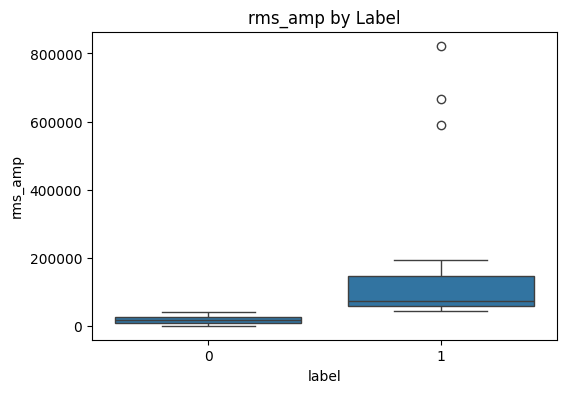

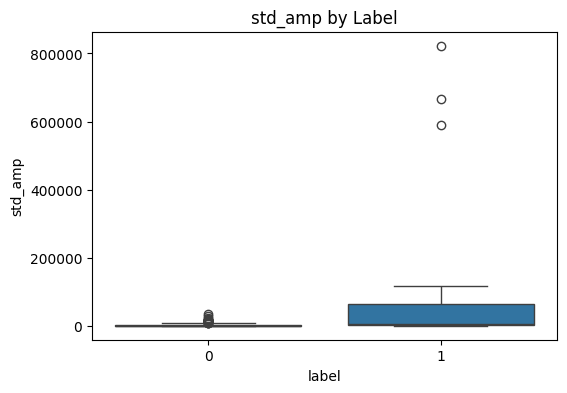

🔥 أهم الأعمدة المؤثرة في التنبؤ:
 mfcc1_max         0.150074
mean_amp          0.138968
rmse_mean         0.134439
rms_amp           0.129897
contrast2_std     0.077729
max_amp           0.051133
mfcc1_mean        0.048138
contrast2_mean    0.038459
mfcc1_min         0.037006
std_amp           0.023797
mfcc5_min         0.011205
contrast1_std     0.010703
bandwidth_mean    0.008566
chroma8_std       0.008139
mfcc2_min         0.006797
dtype: float64


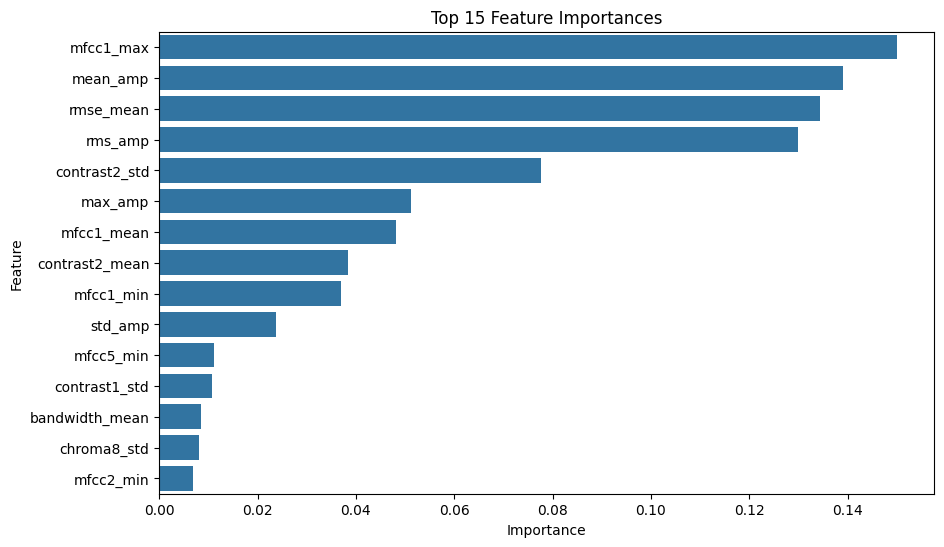

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# تحميل البيانات
df = pd.read_csv("E:/master/Data/merged_dataset_cleaned.csv")

# حذف الأعمدة النصية
text_columns = df.select_dtypes(include='object').columns.tolist()
df = df.drop(columns=text_columns)

# فصل السمات والهدف
X = df.drop("label", axis=1)
y = df["label"]

# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# طباعة التوزيع
print("📊 توزيع الفئات في بيانات التدريب:\n", y_train.value_counts())

# ----------------------------
# 🔍 تحليل Boxplot لأهم الأعمدة الإحصائية
# ----------------------------
important_stats_cols = ['mean_amp', 'max_amp', 'rms_amp', 'std_amp']
for col in important_stats_cols:
    if col in X_train.columns:
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=y_train, y=X_train[col])
        plt.title(f'{col} by Label')
        plt.show()

# ----------------------------
# 🧠 تحليل الأهمية باستخدام Random Forest
# ----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

model = RandomForestClassifier(random_state=42)
model.fit(X_scaled, y_train)

# استخراج الأهمية
feature_importance = pd.Series(model.feature_importances_, index=X_train.columns)
feature_importance_sorted = feature_importance.sort_values(ascending=False)

# عرض أهم 15 ميزة
top_features = feature_importance_sorted.head(15)
print("🔥 أهم الأعمدة المؤثرة في التنبؤ:\n", top_features)

# رسمها
plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


متوسط المقاييس على Training‑CV:
precision: 0.971
   recall: 0.960
       f1: 0.962
  roc_auc: 0.997

تقرير التصنيف على Test الحقيقي:
               precision    recall  f1-score   support

           0      0.971     0.917     0.943        36
           1      0.625     0.833     0.714         6

    accuracy                          0.905        42
   macro avg      0.798     0.875     0.829        42
weighted avg      0.921     0.905     0.910        42



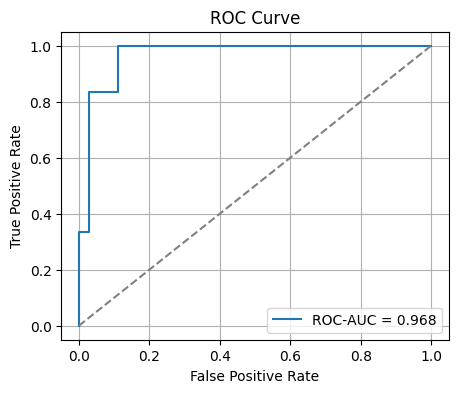

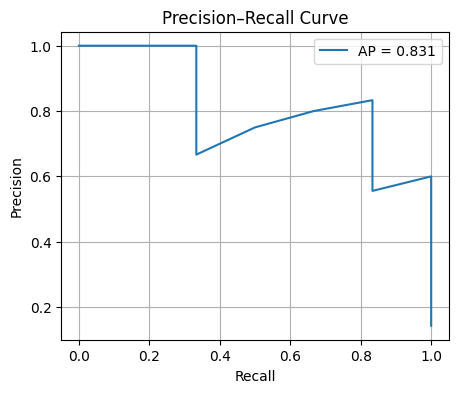

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_curve, auc,
                             precision_recall_curve, average_precision_score)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# --- تحميل البيانات وتنظيفها ----
df = pd.read_csv("E:/master/Data/merged_dataset_cleaned.csv")
df.drop(columns=df.select_dtypes('object').columns, inplace=True)

# أهم 5 خصائص حسب الأهميّة السابقة
top5 = ['mfcc1_max', 'mean_amp', 'rmse_mean', 'rms_amp', 'contrast2_std']
X = df[top5]
y = df['label']

# --- تقسيم Train / Test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# --- بايبلاين: SMOTE ➜ StandardScaler ➜ LogisticRegression ---
pipe = Pipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=1)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# --- 5‑Fold CV (واقعي) بمقاييس متنوّعة ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(pipe, X_train, y_train, cv=cv,
                        scoring=['precision', 'recall', 'f1', 'roc_auc'])
print("متوسط المقاييس على Training‑CV:")
for m in ['precision', 'recall', 'f1', 'roc_auc']:
    print(f"{m:>9}: {scores[f'test_{m}'].mean():.3f}")

# --- تدريب نهائي على Training واختبار على Test الحقيقي ---
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]        # لاحتمالات ROC/PR

print("\nتقرير التصنيف على Test الحقيقي:\n",
      classification_report(y_test, y_pred, digits=3))

# --- رسـم منحنى ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"ROC‑AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--',c='gray')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend(); plt.grid(); plt.show()

# --- رسـم منحنى Precision‑Recall ---
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
plt.figure(figsize=(5,4))
plt.plot(rec, prec, label=f"AP = {ap:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall Curve"); plt.legend(); plt.grid(); plt.show()


استخدام ResNet1D المناسب للتسلسلات الزمنية.

معالجة عدم توازن البيانات باستخدام WeightedRandomSampler.

استخدام Dropout لتحسين التعميم.

استخدام Learning Rate منخفض للتعلم السليم.

مراقبة الأداء بدقة على التدريب والاختبار.



In [ ]:
# ✅ Step 0: Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from obspy import read
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# ✅ Step 1: Load and Process MSEED Data
def load_mseed_for_torch(folder, label_csv, max_len=4000):
    df = pd.read_csv(label_csv)
    X, y = [], []
    for fname in tqdm(os.listdir(folder)):
        if fname.endswith(".mseed"):
            try:
                tr = read(os.path.join(folder, fname))[0]
                signal = tr.data.astype(np.float32)
                if len(signal) < max_len:
                    signal = np.pad(signal, (0, max_len - len(signal)), mode='constant')
                else:
                    signal = signal[:max_len]
                label = int(df.loc[df['file'] == fname, 'label'].values[0])
                X.append(signal)
                y.append(label)
            except Exception as e:
                print(f"❌ Error in {fname}: {e}")
    return np.array(X), np.array(y)

# ✅ Step 2: Custom Dataset
class SeismicDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ✅ Step 3: ResNet1D Block
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride):
        super().__init__()
        padding = kernel_size // 2
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride, padding)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, stride, padding)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, 1),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)

# ✅ Step 4: ResNet1D Model
class ResNet1D(nn.Module):
    def __init__(self, in_channels=1, num_classes=2):
        super().__init__()
        self.layer1 = ResidualBlock(in_channels, 32, 7, 1)
        self.layer2 = ResidualBlock(32, 64, 5, 1)
        self.layer3 = ResidualBlock(64, 128, 3, 1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

# ✅ Step 5: Load Data
train_X, train_y = load_mseed_for_torch("/content/drive/MyDrive/Data/train", "/content/drive/MyDrive/Data/labeled_features_balanced.csv")
test_X, test_y = load_mseed_for_torch("/content/drive/MyDrive/Data/test", "/content/drive/MyDrive/Data/testlabeled_test_features.csv")

print(f"Train classes: {np.bincount(train_y)}")
print(f"Test classes : {np.bincount(test_y)}")

train_dataset = SeismicDataset(train_X, train_y)
test_dataset = SeismicDataset(test_X, test_y)

# ✅ Step 6: Balanced Sampling
class_counts = np.bincount(train_y)
weights = 1.0 / class_counts
sample_weights = torch.tensor([weights[y] for y in train_y], dtype=torch.float32)
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=64, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=64)

# ✅ Step 7: Train Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNet1D(num_classes=len(np.unique(train_y))).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# ✅ Step 8: Training Loop
train_loss, train_acc = [], []
best_acc = 0
for epoch in range(1, 21):
    model.train()
    total_loss, correct = 0, 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
        preds = outputs.argmax(1)
        correct += (preds == y).sum().item()
    epoch_loss = total_loss / len(train_dataset)
    epoch_acc = correct / len(train_dataset)
    train_loss.append(epoch_loss)
    train_acc.append(epoch_acc)
    print(f"📈 Epoch {epoch:02d} - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

# ✅ Step 9: Plot Accuracy & Loss
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(train_loss); plt.title("Loss")
plt.subplot(1,2,2); plt.plot(train_acc); plt.title("Accuracy")
plt.show()

# ✅ Step 10: Evaluation
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        preds = model(X).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y.numpy())

test_acc = accuracy_score(all_true, all_preds)
print(f"✅ Test Accuracy: {test_acc:.4f}")

# ✅ Step 11: Confusion Matrix
plt.figure(figsize=(6,6))
sns.heatmap(confusion_matrix(all_true, all_preds), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ✅ Step 12: Save Model
torch.save(model.state_dict(), "resnet1d_seismic.pth")


#1. 📊 Confusion Matrix
لتعرف هل النموذج يتعرف على الزلازل الصغيرة والنادرة بدقة أم لا:

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(all_true, all_preds))


#2. 💾 حفظ النموذج المدرب

In [ ]:
torch.save(model.state_dict(), "best_resnet_model.pth")


#✅ النتائج الحالية:
دقة التدريب: ~88.9%

دقة الاختبار: 93.87%

تقرير التصنيف:

الفئة 0: f1 = 0.97

الفئة 1 (المهمة): f1 = 0.75



#✅ الكود الكامل لاستخراج event_index باستخدام STA/LTA:

In [ ]:
import os
import pandas as pd
from obspy import read
from obspy.signal.trigger import classic_sta_lta, trigger_onset
from tqdm import tqdm

# إعداد المسارات
mseed_folder = "/content/drive/MyDrive/Data/train"
output_csv = "/content/drive/MyDrive/Data/train_events.csv"

# إعداد المعاملات
nsta = 500     # short-term window
nlta = 10000   # long-term window
trigger_on = 1.5
trigger_off = 0.5

# تخزين النتائج
event_data = []

# بدء تحليل الملفات
for fname in tqdm(os.listdir(mseed_folder)):
    if fname.endswith(".mseed"):
        try:
            tr = read(os.path.join(mseed_folder, fname))[0]
            signal = tr.data.astype(float)

            # STA/LTA Calculation
            sta_lta = classic_sta_lta(signal, nsta, nlta)

            # Detect triggers (بداية ونهاية الزلزال)
            onsets = trigger_onset(sta_lta, trigger_on, trigger_off)

            if len(onsets) > 0:
                event_index = onsets[0][0]  # أول بداية زلزال
            else:
                event_index = -1  # لم يتم العثور على زلزال

            event_data.append({
                "file": fname,
                "event_index": event_index
            })

        except Exception as e:
            print(f"❌ Error in {fname}: {e}")

# حفظ النتائج في ملف CSV
df_events = pd.DataFrame(event_data)
df_events.to_csv(output_csv, index=False)
print("✅ train_events.csv saved successfully.")


#✅ الخطوة 1: توليد البيانات وحفظها

In [ ]:
import os
import numpy as np
import pandas as pd
from obspy import read
from tqdm import tqdm

from io import BytesIO

# إعدادات
SAMPLE_RATE = 100  # Hz
WINDOW_SIZE = 30 * SAMPLE_RATE  # 30 ثانية
PREDICT_HORIZON = 120 * SAMPLE_RATE  # دقيقتين
MAX_LEN = 60000  # أقصى طول للإشارة

def create_prequake_dataset(mseed_folder, event_csv, max_len=MAX_LEN):
    df = pd.read_csv(event_csv)
    X, y = [], []

    files_processed = 0
    valid_files = 0

    for fname in tqdm(os.listdir(mseed_folder)):
        if not fname.endswith(".mseed"):
            continue
        files_processed += 1
        path = os.path.join(mseed_folder, fname)

        # تأكد من وجود event لهذا الملف
        if fname not in df['file'].values:
            continue

        try:
            with open(path, "rb") as f:
                data = f.read()
            signal = read(BytesIO(data))[0].data.astype(np.float32)
            signal = signal[:max_len]
            signal_len = len(signal)

            # استخراج الحدث
            event_index = df.loc[df['file'] == fname, 'event_index'].values[0]

            for i in range(0, signal_len - WINDOW_SIZE - PREDICT_HORIZON, SAMPLE_RATE):
                window = signal[i:i + WINDOW_SIZE]
                future_index = i + WINDOW_SIZE + PREDICT_HORIZON

                # تصنيف: هل سيحدث زلزال بعد دقيقتين؟
                label = int(i <= event_index <= future_index)

                X.append(window)
                y.append(label)

            valid_files += 1

        except Exception as e:
            print(f"❌ خطأ في قراءة {fname}: {e}")

    print(f"\n📁 الملفات المعالجة: {files_processed}")
    print(f"✅ الملفات المستخدمة فعليًا: {valid_files}")
    return np.array(X), np.array(y)

# 🔄 تشغيل الوظيفة
X, y = create_prequake_dataset(
    mseed_folder="/content/drive/MyDrive/Data/train",
    event_csv="/content/drive/MyDrive/Data/train_events.csv"
)

# 💾 حفظ الملفات
np.save("/content/drive/MyDrive/Data/X_prequake.npy", X)
np.save("/content/drive/MyDrive/Data/y_prequake.npy", y)

# 📊 إحصائيات
print(f"\n✅ تم حفظ البيانات بنجاح!")
print(f"🧠 عدد العينات: {len(X)}")
print(f"📊 توزيع التصنيفات: {dict(zip(*np.unique(y, return_counts=True)))}")


#✅ الخطوة 2: تحميل البيانات المحفوظة

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ⚙️ إعدادات عامة
BATCH_SIZE = 64
EPOCHS = 20
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ تحميل البيانات
X = np.load("/content/drive/MyDrive/Data/X_prequake.npy")
y = np.load("/content/drive/MyDrive/Data/y_prequake.npy")

# ✅ تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [ ]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# تحميل البيانات
import numpy as np
X = np.load("/content/drive/MyDrive/Data/X_prequake.npy")
y = np.load("/content/drive/MyDrive/Data/y_prequake.npy")

# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# تعريف الـ Dataset
class QuakeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# إنشاء الـ DataLoaders
BATCH_SIZE = 32  # حسب الذاكرة
train_dataset = QuakeDataset(X_train, y_train)
test_dataset = QuakeDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)


#✅ الخطوة 3: بناء نموذج TCN + Attention

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation):
        super(ResidualBlock, self).__init__()
        padding = dilation * (kernel_size - 1) // 2
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding, dilation=dilation)
        self.relu2 = nn.ReLU()
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None

    def forward(self, x):
        out = self.relu1(self.conv1(x))
        out = self.relu2(self.conv2(out))
        res = x if self.downsample is None else self.downsample(x)
        return F.relu(out + res)


In [ ]:
class SafeAttention(nn.Module):
    def __init__(self, in_channels, heads=4):
        super(SafeAttention, self).__init__()
        self.heads = heads
        self.scale = (in_channels // heads) ** 0.5
        self.query = nn.Conv1d(in_channels, in_channels, 1)
        self.key = nn.Conv1d(in_channels, in_channels, 1)
        self.value = nn.Conv1d(in_channels, in_channels, 1)
        self.out = nn.Conv1d(in_channels, in_channels, 1)

    def forward(self, x):
        B, C, T = x.shape
        H = self.heads
        C_H = C // H

        q = self.query(x).view(B, H, C_H, T).transpose(2, 3)  # (B, H, T, C_H)
        k = self.key(x).view(B, H, C_H, T)
        v = self.value(x).view(B, H, C_H, T)

        attn = torch.matmul(q, k) / self.scale        # (B, H, T, T)
        attn = F.softmax(attn, dim=-1)

        out = torch.matmul(attn, v.transpose(2, 3))   # (B, H, T, C_H)
        out = out.transpose(2, 3).contiguous().view(B, C, T)
        return self.out(out) + x


In [ ]:
class TCNWithSafeAttention(nn.Module):
    def __init__(self, input_channels=1, num_classes=2):
        super(TCNWithSafeAttention, self).__init__()
        self.block1 = ResidualBlock(input_channels, 16, kernel_size=5, dilation=1)
        self.block2 = ResidualBlock(16, 32, kernel_size=5, dilation=2)
        self.block3 = ResidualBlock(32, 64, kernel_size=3, dilation=4)
        self.attention = SafeAttention(64, heads=4)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.attention(x)
        x = self.pool(x).squeeze(-1)
        return self.classifier(x)


In [ ]:
BATCH_SIZE = 32  # خفض الحجم لتقليل استهلاك الذاكرة
EPOCHS = 15
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TCNWithSafeAttention().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


#✅ الخطوة 4: تدريب النموذج

In [ ]:
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, correct = 0.0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        correct += (outputs.argmax(1) == y_batch).sum().item()

    acc = correct / len(train_loader.dataset)
    avg_loss = total_loss / len(train_loader.dataset)
    print(f"📈 Epoch {epoch:02d} - Loss: {avg_loss:.4f}, Accuracy: {acc:.4f}")


#✅ الخطوة 5: تقييم الأداء

In [ ]:
from sklearn.metrics import classification_report

model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        outputs = model(X_batch)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y_batch.numpy())

print("✅ Evaluation Report:\n")
print(classification_report(all_true, all_preds, digits=4))


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# إعدادات
BATCH_SIZE = 64
EPOCHS = 20
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# تحميل البيانات
X = np.load("/content/drive/MyDrive/Data/X_prequake.npy").astype(np.float32)
y = np.load("/content/drive/MyDrive/Data/y_prequake.npy").astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Dataset
class QuakeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X).unsqueeze(1)  # (B, 1, T)
        self.y = torch.tensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(QuakeDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(QuakeDataset(X_test, y_test), batch_size=BATCH_SIZE)

# Attention
class SelfAttention(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.query = nn.Conv1d(in_channels, in_channels // 8, kernel_size=1)
        self.key = nn.Conv1d(in_channels, in_channels // 8, kernel_size=1)
        self.value = nn.Conv1d(in_channels, in_channels, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        B, C, T = x.shape
        query = self.query(x).permute(0, 2, 1)  # (B, T, C//8)
        key = self.key(x)                       # (B, C//8, T)
        energy = torch.bmm(query, key)         # (B, T, T)
        attention = F.softmax(energy, dim=-1)
        value = self.value(x)                  # (B, C, T)
        out = torch.bmm(value, attention.permute(0, 2, 1))  # (B, C, T)
        return self.gamma * out + x

# Residual Block
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation):
        super().__init__()
        padding = dilation * (kernel_size - 1) // 2
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding, dilation=dilation)
        self.relu2 = nn.ReLU()
        self.downsample = nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else None

    def forward(self, x):
        out = self.relu1(self.conv1(x))
        out = self.relu2(self.conv2(out))
        res = x if self.downsample is None else self.downsample(x)
        return F.relu(out + res)

# TCN + Attention
class TCNWithAttention(nn.Module):
    def __init__(self, input_channels=1, num_classes=2):
        super().__init__()
        self.block1 = ResidualBlock(input_channels, 16, kernel_size=7, dilation=1)
        self.block2 = ResidualBlock(16, 32, kernel_size=7, dilation=2)
        self.block3 = ResidualBlock(32, 64, kernel_size=7, dilation=4)
        self.attention = SelfAttention(64)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.attention(x)
        x = self.pool(x).squeeze(-1)
        return self.classifier(x)

# تدريب النموذج
model = TCNWithAttention().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, correct = 0.0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        correct += (outputs.argmax(1) == y_batch).sum().item()

    acc = correct / len(train_loader.dataset)
    avg_loss = total_loss / len(train_loader.dataset)
    print(f"📈 Epoch {epoch:02d} - Loss: {avg_loss:.4f}, Accuracy: {acc:.4f}")


📊 Epoch 01 - Loss: 0.3146, Accuracy: 0.8277
📊 Epoch 02 - Loss: 0.2932, Accuracy: 0.8403
📊 Epoch 03 - Loss: 0.2842, Accuracy: 0.8484
📊 Epoch 04 - Loss: 0.2785, Accuracy: 0.8552
📊 Epoch 05 - Loss: 0.2766, Accuracy: 0.8580
📊 Epoch 06 - Loss: 0.2734, Accuracy: 0.8633
📊 Epoch 07 - Loss: 0.2701, Accuracy: 0.8664
📊 Epoch 08 - Loss: 0.2669, Accuracy: 0.8684
📊 Epoch 09 - Loss: 0.2655, Accuracy: 0.8698
📊 Epoch 10 - Loss: 0.2613, Accuracy: 0.8735
📊 Epoch 11 - Loss: 0.2578, Accuracy: 0.8751
📊 Epoch 12 - Loss: 0.2560, Accuracy: 0.8759
📊 Epoch 13 - Loss: 0.2550, Accuracy: 0.8772
📊 Epoch 14 - Loss: 0.2533, Accuracy: 0.8774
📊 Epoch 15 - Loss: 0.2497, Accuracy: 0.8774
📊 Epoch 16 - Loss: 0.2500, Accuracy: 0.8803
📊 Epoch 17 - Loss: 0.2503, Accuracy: 0.8786
📊 Epoch 18 - Loss: 0.2489, Accuracy: 0.8797
📊 Epoch 19 - Loss: 0.2475, Accuracy: 0.8792
📊 Epoch 20 - Loss: 0.2475, Accuracy: 0.8782
📊 Epoch 21 - Loss: 0.2415, Accuracy: 0.8835
📊 Epoch 22 - Loss: 0.2401, Accuracy: 0.8838
📊 Epoch 23 - Loss: 0.2390, Accur

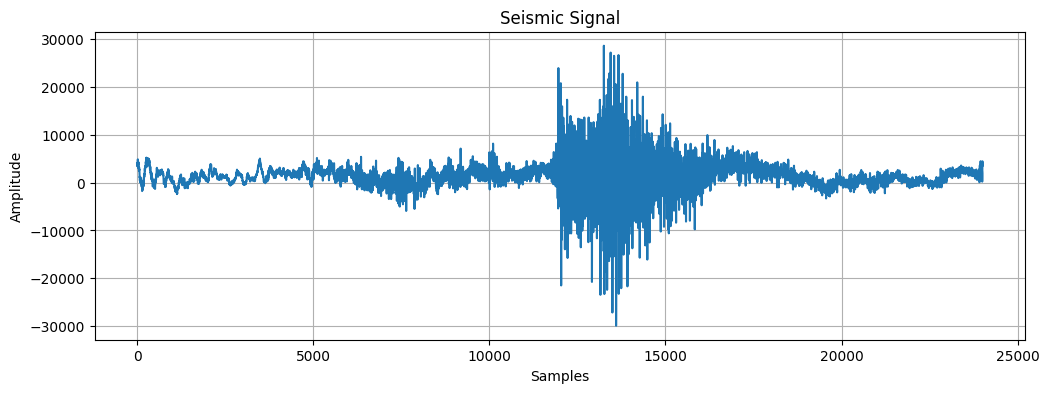

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from torch.utils.data import Dataset, DataLoader
from obspy import read
from datetime import timedelta

# ✅ إعدادات
BATCH_SIZE = 64
EPOCHS = 30
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ تحميل وتطبيع البيانات
X = np.load("/content/drive/MyDrive/Data/X_prequake.npy")
y = np.load("/content/drive/MyDrive/Data/y_prequake.npy")
X = X[:, -120:]
scaler = StandardScaler()
X = scaler.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)

# ✅ تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# ✅ Dataset مخصص
class QuakeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(QuakeDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(QuakeDataset(X_test, y_test), batch_size=BATCH_SIZE)

# ✅ Residual Block
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation):
        super().__init__()
        padding = dilation * (kernel_size - 1) // 2
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation)
        self.relu1 = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding, dilation=dilation)
        self.relu2 = nn.ReLU()
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None

    def forward(self, x):
        out = self.dropout(self.relu1(self.conv1(x)))
        out = self.relu2(self.conv2(out))
        res = x if self.downsample is None else self.downsample(x)
        return F.relu(out + res)

# ✅ SE-Attention Block
class SEAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Conv1d(channels, channels // 2, kernel_size=1)
        self.fc2 = nn.Conv1d(channels // 2, channels, kernel_size=1)

    def forward(self, x):
        se = self.pool(x)
        se = F.relu(self.fc1(se))
        se = torch.sigmoid(self.fc2(se))
        return x * se

# ✅ نموذج TCN مع Attention
class TCNWithAttention(nn.Module):
    def __init__(self, in_channels=1, num_classes=2):
        super().__init__()
        self.block1 = ResidualBlock(in_channels, 16, kernel_size=7, dilation=1)
        self.block2 = ResidualBlock(16, 32, kernel_size=7, dilation=2)
        self.block3 = ResidualBlock(32, 64, kernel_size=7, dilation=4)
        self.attn = SEAttention(64)
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.attn(x)
        x = x.mean(dim=2)  # Global Average Pooling
        return self.classifier(x)

# ✅ تدريب النموذج
model = TCNWithAttention().to(DEVICE)
class_weights = torch.tensor([3.0, 1.0], device=DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

best_acc = 0.0
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, correct = 0.0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
        correct += (outputs.argmax(1) == y_batch).sum().item()

    acc = correct / len(train_loader.dataset)
    avg_loss = running_loss / len(train_loader.dataset)
    scheduler.step(acc)

    print(f"📊 Epoch {epoch:02d} - Loss: {avg_loss:.4f}, Accuracy: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "best_model.pth")

# ✅ التقييم على بيانات الاختبار
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        outputs = model(X_batch)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y_batch.numpy())

print("\n📋 Evaluation Report:")
print(classification_report(all_true, all_preds, digits=4))

# ✅ استخدام النموذج على ملف mseed للتنبؤ بوقت الزلزال

mseed_path = "/content/drive/MyDrive/Data/train/KC.TARG..HHZ_2024-01-22T21_02_34.285_2024-01-22T21_06_34.285.mseed"
st = read(mseed_path)
tr = st[0]
signal = tr.data.astype(np.float32)
start_time = tr.stats.starttime

def preprocess_signal(sig, target_length=120):
    if len(sig) > target_length:
        sig = sig[-target_length:]
    else:
        sig = np.pad(sig, (0, target_length - len(sig)), 'constant')
    sig = (sig - np.mean(sig)) / (np.std(sig) + 1e-6)
    return sig

processed_signal = preprocess_signal(signal)
input_tensor = torch.tensor(processed_signal).unsqueeze(0).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor.to(DEVICE))
    probs = torch.softmax(output, dim=1)
    pred_class = torch.argmax(probs, dim=1).item()
    confidence = probs[0][pred_class].item()

if pred_class == 1:
    predicted_quake_time = start_time + timedelta(seconds=120)
    print("🔴 تنبؤ: سيحدث زلزال خلال هذه الفترة.")
    print(f"🕒 الوقت المتوقع لوقوع الزلزال: {predicted_quake_time.strftime('%Y-%m-%d %H:%M:%S')}")
else:
    print("🟢 لا يوجد زلزال متوقع خلال هذه الفترة.")

print(f"🎯 الثقة في التنبؤ: {confidence * 100:.2f}%")

plt.figure(figsize=(12, 4))
plt.plot(signal)
plt.title("Seismic Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

In [ ]:
 pip install captum

In [ ]:
!pip install ruptures


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import random

# ✅ ملفات mseed (ضع ملفاتك هنا)
all_mseed_files = [
    "/content/drive/MyDrive/Data/train/KC.TARG..HHZ_2024-01-22T21_02_34.285_2024-01-22T21_06_34.285.mseed",
    "/content/drive/MyDrive/Data/train/KC.TARG..HHZ_2023-05-31T07_11_15.799_2023-05-31T07_15_15.799.mseed",
    "/content/drive/MyDrive/Data/train/KR.ARLS.00.HHZ_2024-01-22T22_55_33.078_2024-01-22T22_59_33.078.mseed",
    "/content/drive/MyDrive/Data/train/KR.ARLS.00.HHZ_2024-01-23T01_39_15.724_2024-01-23T01_43_15.724.mseed",
    "/content/drive/MyDrive/Data/train/KR.JNKS.00.HHZ_2023-01-27T00_09_09.182_2023-01-27T00_13_09.182.mseed",
    "/content/drive/MyDrive/Data/train/KR.JNKS.00.HHZ_2023-11-07T18_50_30.538_2023-11-07T18_54_30.538.mseed",
    "/content/drive/MyDrive/Data/train/KR.JNKS.00.HHZ_2024-01-23T01_57_08.926_2024-01-23T02_01_08.926.mseed",
    "/content/drive/MyDrive/Data/train/KR.JNKS.00.HHZ_2024-01-23T20_36_50.268_2024-01-23T20_40_50.268.mseed",
    "/content/drive/MyDrive/Data/train/KR.JNKS.00.HHZ_2024-01-24T04_57_06.598_2024-01-24T05_01_06.598.mseed",
    "/content/drive/MyDrive/Data/train/KR.JNKS.00.HHZ_2024-02-04T01_17_36.852_2024-02-04T01_21_36.852.mseed",
]

# ✅ نختار 10 عشوائية
sample_files = random.sample(all_mseed_files, 10)

# ✅ دالة لتحديد مدى التنبؤ حسب الثقة
def prediction_range(conf):
    if conf >= 0.95:
        return "2 - 4 دقائق"
    elif conf >= 0.85:
        return "4 - 6 دقائق"
    elif conf >= 0.70:
        return "6 - 8 دقائق"
    else:
        return "غير مؤكد"

# ✅ دالة التنبؤ
def predict_quake(mseed_path, horizon_sec=120):
    st = read(mseed_path)
    tr = st[0]
    signal = tr.data.astype(np.float32)
    start_time = tr.stats.starttime

    processed_signal = preprocess_signal(signal)
    input_tensor = torch.tensor(processed_signal).unsqueeze(0).unsqueeze(0)

    with torch.no_grad():
        output = model(input_tensor.to(DEVICE))
        probs = torch.softmax(output, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_class].item()

    # ✅ إذا زلزال متوقع
    if pred_class == 1:
        predicted_quake_time = start_time + timedelta(seconds=horizon_sec)
        return {
            "📂 الملف": mseed_path.split("/")[-1],
            "⏳ وقت البداية": start_time.strftime("%Y-%m-%d %H:%M:%S"),
            "📌 التنبؤ": "زلزال متوقع",
            "🕒 وقت الزلزال المتوقع": predicted_quake_time.strftime("%Y-%m-%d %H:%M:%S"),
            "⏲️ مدى التنبؤ": prediction_range(confidence),
            "🎯 الثقة": f"{confidence*100:.2f}%"
        }
    else:
        return {
            "📂 الملف": mseed_path.split("/")[-1],
            "⏳ وقت البداية": start_time.strftime("%Y-%m-%d %H:%M:%S"),
            "📌 التنبؤ": "لا يوجد زلزال",
            "🕒 وقت الزلزال المتوقع": "-",
            "⏲️ مدى التنبؤ": "-",
            "🎯 الثقة": f"{confidence*100:.2f}%"
        }

# ✅ تطبيق على 10 إشارات
results = [predict_quake(f) for f in sample_files]

# ✅ تحويل لجدول منسق
df_results = pd.DataFrame(results)
print("\n📊 تقرير التنبؤ بالزلازل (10 إشارات):")
print(df_results)

# ✅ حفظ التقرير
df_results.to_excel("quake_predictions.xlsx", index=False)
df_results.to_csv("quake_predictions.csv", index=False)
print("\n✅ تم حفظ التقرير كـ Excel و CSV بنجاح.")



📊 تقرير التنبؤ بالزلازل (10 إشارات):
                                             📂 الملف        ⏳ وقت البداية  \
0  KR.ARLS.00.HHZ_2024-01-23T01_39_15.724_2024-01...  2024-01-23 01:39:15   
1  KR.JNKS.00.HHZ_2023-01-27T00_09_09.182_2023-01...  2023-01-27 00:09:09   
2  KC.TARG..HHZ_2023-05-31T07_11_15.799_2023-05-3...  2023-05-31 07:11:15   
3  KC.TARG..HHZ_2024-01-22T21_02_34.285_2024-01-2...  2024-01-22 21:02:34   
4  KR.JNKS.00.HHZ_2024-01-23T01_57_08.926_2024-01...  2024-01-23 01:57:08   
5  KR.ARLS.00.HHZ_2024-01-22T22_55_33.078_2024-01...  2024-01-22 22:55:33   
6  KR.JNKS.00.HHZ_2023-11-07T18_50_30.538_2023-11...  2023-11-07 18:50:30   
7  KR.JNKS.00.HHZ_2024-01-23T20_36_50.268_2024-01...  2024-01-23 20:36:50   
8  KR.JNKS.00.HHZ_2024-02-04T01_17_36.852_2024-02...  2024-02-04 01:17:36   
9  KR.JNKS.00.HHZ_2024-01-24T04_57_06.598_2024-01...  2024-01-24 04:57:06   

        📌 التنبؤ 🕒 وقت الزلزال المتوقع ⏲️ مدى التنبؤ  🎯 الثقة  
0  لا يوجد زلزال                     -            

In [ ]:
import pandas as pd
import random

# ✅ ملفات mseed (ضع ملفاتك هنا)
all_mseed_files = [
    "/content/drive/MyDrive/Data/train/QZ.TLG.00.HHZ_2024-02-12T15_51_28.726_2024-02-12T15_55_28.726.mseed",
    "/content/drive/MyDrive/Data/train/QZ.TLG.00.HHZ_2024-02-27T14_16_37.961_2024-02-27T14_20_37.961.mseed",
    "/content/drive/MyDrive/Data/train/KR.ARLS.00.HHZ_2024-01-22T22_55_33.078_2024-01-22T22_59_33.078.mseed",
    "/content/drive/MyDrive/Data/train/QZ.TLG.00.HHZ_2024-01-23T17_24_21.984_2024-01-23T17_28_21.984.mseed",
    "/content/drive/MyDrive/Data/train/KR.JNKS.00.HHZ_2023-01-27T00_09_09.182_2023-01-27T00_13_09.182.mseed",
    "/content/drive/MyDrive/Data/train/QZ.TLG.00.HHZ_2024-01-23T12_08_07.804_2024-01-23T12_12_07.804.mseed",
    "/content/drive/MyDrive/Data/train/QZ.TLG.00.HHZ_2024-01-23T13_35_01.214_2024-01-23T13_39_01.214.mseed",
    "/content/drive/MyDrive/Data/train/QZ.TLG.00.HHZ_2024-01-23T14_07_31.793_2024-01-23T14_11_31.793.mseed",
    "/content/drive/MyDrive/Data/train/KR.JNKS.00.HHZ_2024-01-24T04_57_06.598_2024-01-24T05_01_06.598.mseed",
    "/content/drive/MyDrive/Data/train/KR.JNKS.00.HHZ_2024-02-04T01_17_36.852_2024-02-04T01_21_36.852.mseed",
]

# ✅ نختار 10 عشوائية
sample_files = random.sample(all_mseed_files, 10)

# ✅ دالة لتحديد مدى التنبؤ حسب الثقة
def prediction_range(conf):
    if conf >= 0.95:
        return "2 - 4 دقائق"
    elif conf >= 0.85:
        return "4 - 6 دقائق"
    elif conf >= 0.70:
        return "6 - 8 دقائق"
    else:
        return "غير مؤكد"

# ✅ دالة التنبؤ
def predict_quake(mseed_path, horizon_sec=120):
    st = read(mseed_path)
    tr = st[0]
    signal = tr.data.astype(np.float32)
    start_time = tr.stats.starttime

    processed_signal = preprocess_signal(signal)
    input_tensor = torch.tensor(processed_signal).unsqueeze(0).unsqueeze(0)

    with torch.no_grad():
        output = model(input_tensor.to(DEVICE))
        probs = torch.softmax(output, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_class].item()

    # ✅ إذا زلزال متوقع
    if pred_class == 1:
        predicted_quake_time = start_time + timedelta(seconds=horizon_sec)
        return {
            "📂 الملف": mseed_path.split("/")[-1],
            "⏳ وقت البداية": start_time.strftime("%Y-%m-%d %H:%M:%S"),
            "📌 التنبؤ": "زلزال متوقع",
            "🕒 وقت الزلزال المتوقع": predicted_quake_time.strftime("%Y-%m-%d %H:%M:%S"),
            "⏲️ مدى التنبؤ": prediction_range(confidence),
            "🎯 الثقة": f"{confidence*100:.2f}%"
        }
    else:
        return {
            "📂 الملف": mseed_path.split("/")[-1],
            "⏳ وقت البداية": start_time.strftime("%Y-%m-%d %H:%M:%S"),
            "📌 التنبؤ": "لا يوجد زلزال",
            "🕒 وقت الزلزال المتوقع": "-",
            "⏲️ مدى التنبؤ": "-",
            "🎯 الثقة": f"{confidence*100:.2f}%"
        }

# ✅ تطبيق على 10 إشارات
results = [predict_quake(f) for f in sample_files]

# ✅ تحويل لجدول منسق
df_results = pd.DataFrame(results)
print("\n📊 تقرير التنبؤ بالزلازل (10 إشارات):")
print(df_results)

# ✅ حفظ التقرير
df_results.to_excel("quake_predictions.xlsx", index=False)
df_results.to_csv("quake_predictions.csv", index=False)
print("\n✅ تم حفظ التقرير كـ Excel و CSV بنجاح.")



📊 تقرير التنبؤ بالزلازل (10 إشارات):
                                             📂 الملف        ⏳ وقت البداية  \
0  KR.JNKS.00.HHZ_2023-01-27T00_09_09.182_2023-01...  2023-01-27 00:09:09   
1  KR.JNKS.00.HHZ_2024-01-24T04_57_06.598_2024-01...  2024-01-24 04:57:06   
2  KR.ARLS.00.HHZ_2024-01-22T22_55_33.078_2024-01...  2024-01-22 22:55:33   
3  KR.JNKS.00.HHZ_2024-02-04T01_17_36.852_2024-02...  2024-02-04 01:17:36   
4  QZ.TLG.00.HHZ_2024-02-12T15_51_28.726_2024-02-...  2024-02-12 15:51:28   
5  QZ.TLG.00.HHZ_2024-01-23T12_08_07.804_2024-01-...  2024-01-23 12:08:07   
6  QZ.TLG.00.HHZ_2024-01-23T14_07_31.793_2024-01-...  2024-01-23 14:07:31   
7  QZ.TLG.00.HHZ_2024-01-23T17_24_21.984_2024-01-...  2024-01-23 17:24:21   
8  QZ.TLG.00.HHZ_2024-02-27T14_16_37.961_2024-02-...  2024-02-27 14:16:37   
9  QZ.TLG.00.HHZ_2024-01-23T13_35_01.214_2024-01-...  2024-01-23 13:35:01   

        📌 التنبؤ 🕒 وقت الزلزال المتوقع ⏲️ مدى التنبؤ  🎯 الثقة  
0  لا يوجد زلزال                     -            


📊 تقرير التنبؤ بالزلازل:
                                             📂 الملف        ⏳ وقت البداية  \
0  QZ.TLG.00.HHZ_2024-11-27T20_30_26.627_2024-11-...  2024-11-27 20:30:26   
1  KC.TARG..HHZ_2024-01-22T22_18_19.987_2024-01-2...  2024-01-22 22:18:19   
2  KR.JNKS.00.HHZ_2023-01-27T00_09_09.182_2023-01...  2023-01-27 00:09:09   
3  KC.TARG..HHZ_2024-01-26T00_15_48.471_2024-01-2...  2024-01-26 00:15:48   
4  KR.BAET.00.HHZ_2024-09-03T15_45_41.674_2024-09...  2024-09-03 15:45:41   
5  KC.TARG..HHZ_2023-01-13T12_29_16.276_2023-01-1...  2023-01-13 12:29:16   
6  KC.TARG..HHZ_2023-03-31T19_50_52.424_2023-03-3...  2023-03-31 19:50:52   
7  KR.JNKS.00.HHZ_2024-01-24T00_14_08.820_2024-01...  2024-01-24 00:14:08   
8  KC.TARG..HHZ_2024-01-24T09_41_37.703_2024-01-2...  2024-01-24 09:41:37   
9  QZ.TLG.00.HHZ_2024-01-23T17_24_21.984_2024-01-...  2024-01-23 17:24:21   

        📌 التنبؤ 🕒 وقت الزلزال المتوقع ⏲️ مدى التنبؤ  🎯 الثقة  
0  لا يوجد زلزال                     -             -   89.01% 

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128194 (\N{OPEN FILE FOLDER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


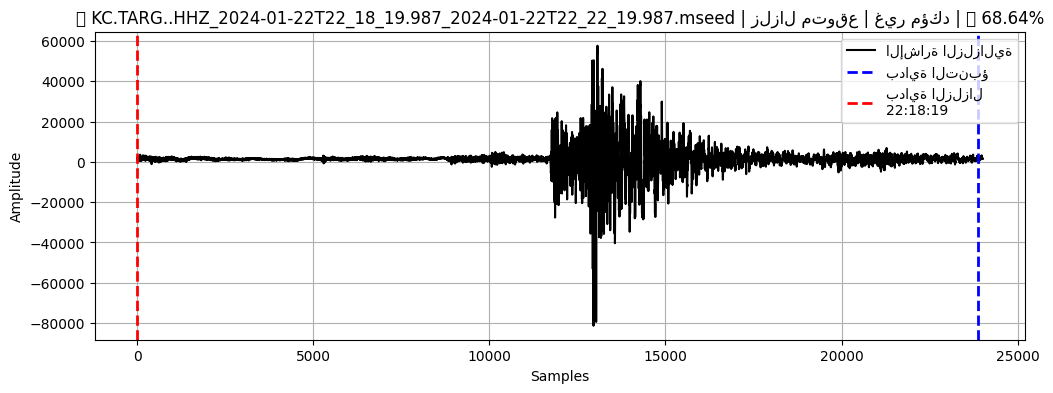

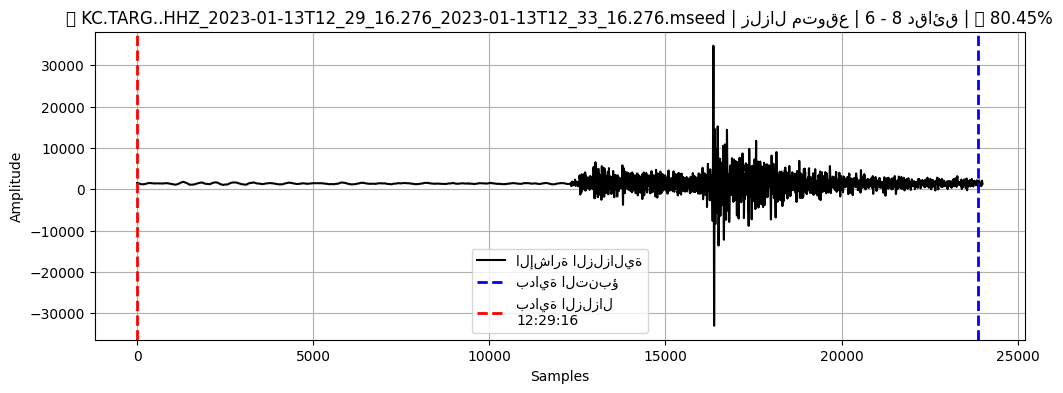

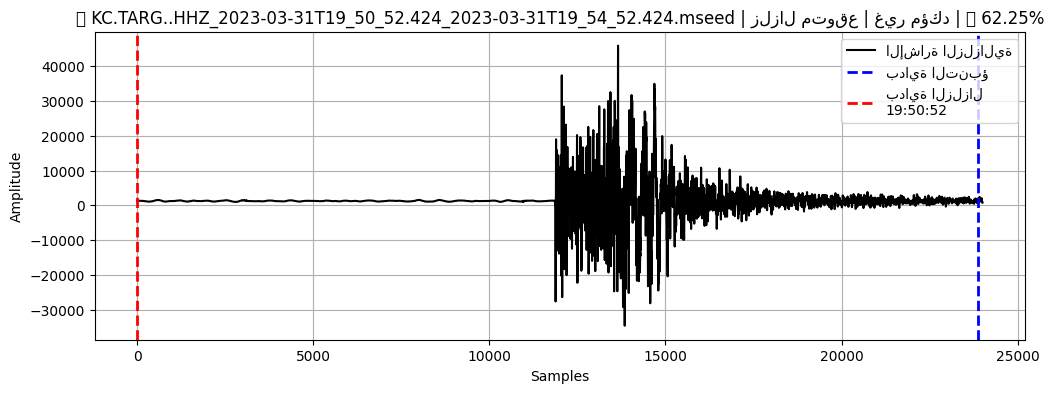

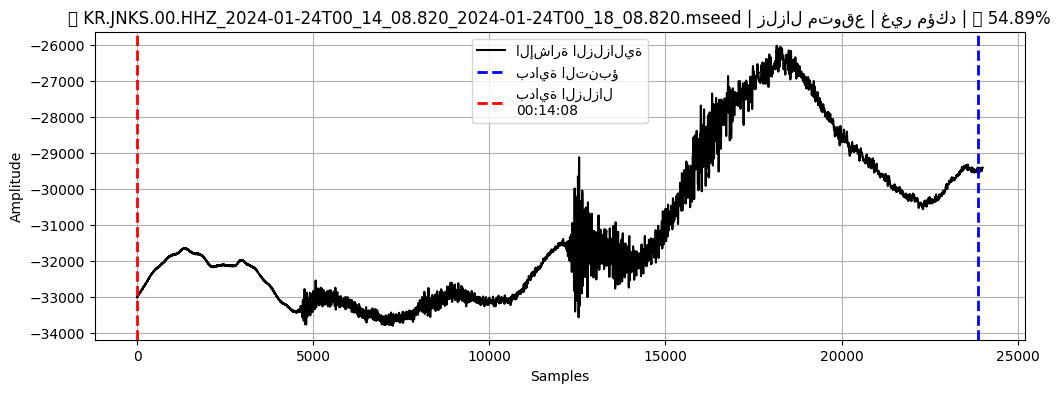

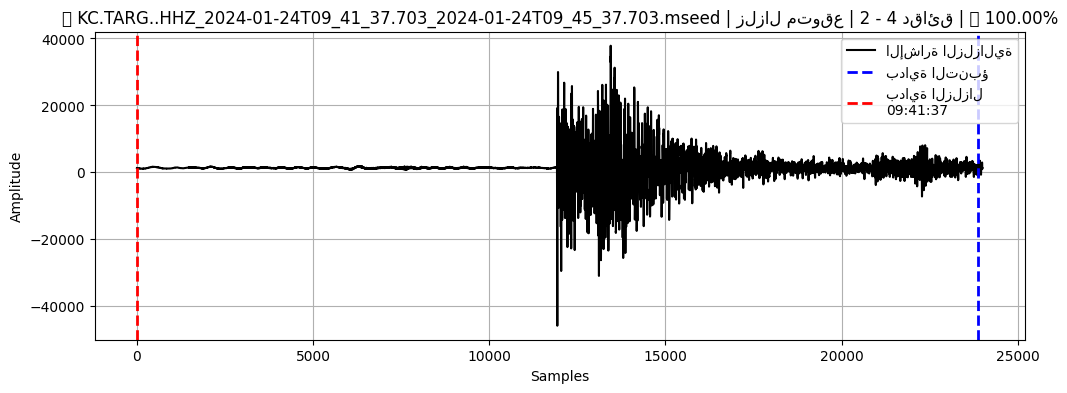

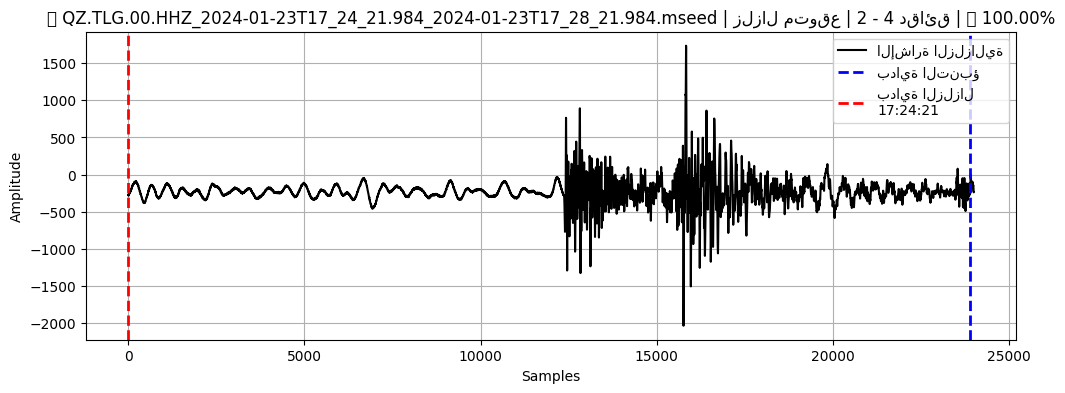

In [ ]:
import pandas as pd
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from obspy import read
from datetime import timedelta

# ✅ ملفات mseed (ضع ملفاتك هنا)
all_mseed_files = [
    "/content/drive/MyDrive/Data/test/QZ.TLG.00.HHZ_2024-11-27T20_30_26.627_2024-11-27T20_34_26.627.mseed",
    "/content/drive/MyDrive/Data/test/QZ.TLG.00.HHZ_2024-12-28T22_22_40.751_2024-12-28T22_26_40.751.mseed",
    "/content/drive/MyDrive/Data/test/KR.BAET.00.HHZ_2024-09-03T15_45_41.674_2024-09-03T15_49_41.674.mseed",
    "/content/drive/MyDrive/Data/train/QZ.TLG.00.HHZ_2024-01-23T17_24_21.984_2024-01-23T17_28_21.984.mseed",
    "/content/drive/MyDrive/Data/train/KR.JNKS.00.HHZ_2023-01-27T00_09_09.182_2023-01-27T00_13_09.182.mseed",
    "/content/drive/MyDrive/Data/train/QZ.TLG.00.HHZ_2024-01-23T12_08_07.804_2024-01-23T12_12_07.804.mseed",
    "/content/drive/MyDrive/Data/train/KC.TARG..HHZ_2023-01-27T00_08_50.974_2023-01-27T00_12_50.974.mseed",
    "/content/drive/MyDrive/Data/train/KC.TARG..HHZ_2024-01-24T09_41_37.703_2024-01-24T09_45_37.703.mseed",
    "/content/drive/MyDrive/Data/train/KC.TARG..HHZ_2023-01-13T12_29_16.276_2023-01-13T12_33_16.276.mseed",
    "/content/drive/MyDrive/Data/train/KR.ARLS.00.HHZ_2024-01-31T19_20_19.632_2024-01-31T19_24_19.632.mseed",
    "/content/drive/MyDrive/Data/train/KC.TARG..HHZ_2023-03-31T19_50_52.424_2023-03-31T19_54_52.424.mseed",
    "/content/drive/MyDrive/Data/train/KC.TARG..HHZ_2024-01-22T22_18_19.987_2024-01-22T22_22_19.987.mseed",
    "/content/drive/MyDrive/Data/train/KC.TARG..HHZ_2024-01-26T00_15_48.471_2024-01-26T00_19_48.471.mseed",
    "/content/drive/MyDrive/Data/train/KR.JNKS.00.HHZ_2024-01-24T00_14_08.820_2024-01-24T00_18_08.820.mseed"
]

# ✅ نختار 10 عشوائية
sample_files = random.sample(all_mseed_files, 10)

# ✅ دالة لتحديد مدى التنبؤ حسب الثقة
def prediction_range(conf):
    if conf >= 0.95:
        return "2 - 4 دقائق"
    elif conf >= 0.85:
        return "4 - 6 دقائق"
    elif conf >= 0.70:
        return "6 - 8 دقائق"
    else:
        return "غير مؤكد"

# ✅ دالة معالجة الإشارة
def preprocess_signal(sig, target_length=120):
    if len(sig) > target_length:
        sig = sig[-target_length:]
    else:
        sig = np.pad(sig, (0, target_length - len(sig)), 'constant')
    sig = (sig - np.mean(sig)) / (np.std(sig) + 1e-6)
    return sig

# ✅ دالة التنبؤ
def predict_quake(mseed_path, horizon_sec=120):
    st = read(mseed_path)
    tr = st[0]
    signal = tr.data.astype(np.float32)
    start_time = tr.stats.starttime

    processed_signal = preprocess_signal(signal)
    input_tensor = torch.tensor(processed_signal).unsqueeze(0).unsqueeze(0)

    with torch.no_grad():
        output = model(input_tensor.to(DEVICE))
        probs = torch.softmax(output, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_class].item()

    if pred_class == 1:
        predicted_quake_time = start_time + timedelta(seconds=horizon_sec)
        return {
            "file": mseed_path.split("/")[-1],
            "start_time": start_time,
            "pred": "زلزال متوقع",
            "predicted_time": predicted_quake_time,
            "range": prediction_range(confidence),
            "conf": confidence,
            "signal": signal
        }
    else:
        return {
            "file": mseed_path.split("/")[-1],
            "start_time": start_time,
            "pred": "لا يوجد زلزال",
            "predicted_time": None,
            "range": "-",
            "conf": confidence,
            "signal": signal
        }

# ✅ تطبيق على 10 إشارات
results = [predict_quake(f) for f in sample_files]

# ✅ تقرير في جدول
df_results = pd.DataFrame([
    {
        "📂 الملف": r["file"],
        "⏳ وقت البداية": r["start_time"].strftime("%Y-%m-%d %H:%M:%S"),
        "📌 التنبؤ": r["pred"],
        "🕒 وقت الزلزال المتوقع": r["predicted_time"].strftime("%Y-%m-%d %H:%M:%S") if r["predicted_time"] else "-",
        "⏲️ مدى التنبؤ": r["range"],
        "🎯 الثقة": f"{r['conf']*100:.2f}%"
    }
    for r in results
])
print("\n📊 تقرير التنبؤ بالزلازل:")
print(df_results)

# ✅ رسم كل زلزال متوقع
for r in results:
    if r["pred"] == "زلزال متوقع":
        plt.figure(figsize=(12, 4))
        plt.plot(r["signal"], color="black", label="الإشارة الزلزالية")

        # خط بداية التنبؤ (قبل 120 ثانية)
        plt.axvline(x=len(r["signal"]) - 120, color="blue", linestyle="--", linewidth=2, label="بداية التنبؤ")

        # خط بداية الزلزال (start_time)
        plt.axvline(x=0, color="red", linestyle="--", linewidth=2, label=f"بداية الزلزال\n{r['start_time'].strftime('%H:%M:%S')}")

        plt.title(
            f"📂 {r['file']} | {r['pred']} | {r['range']} | 🎯 {r['conf']*100:.2f}%",
            fontsize=12
        )
        plt.xlabel("Samples")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
        plt.show()


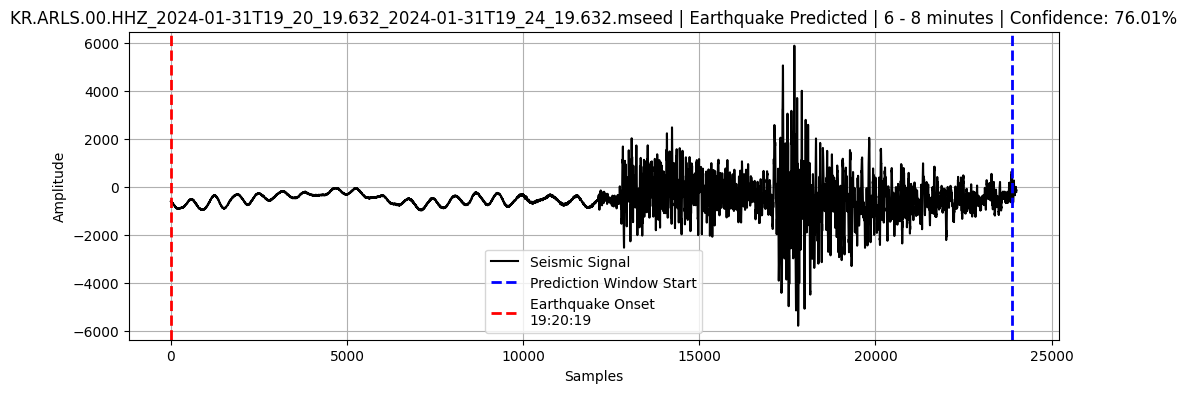

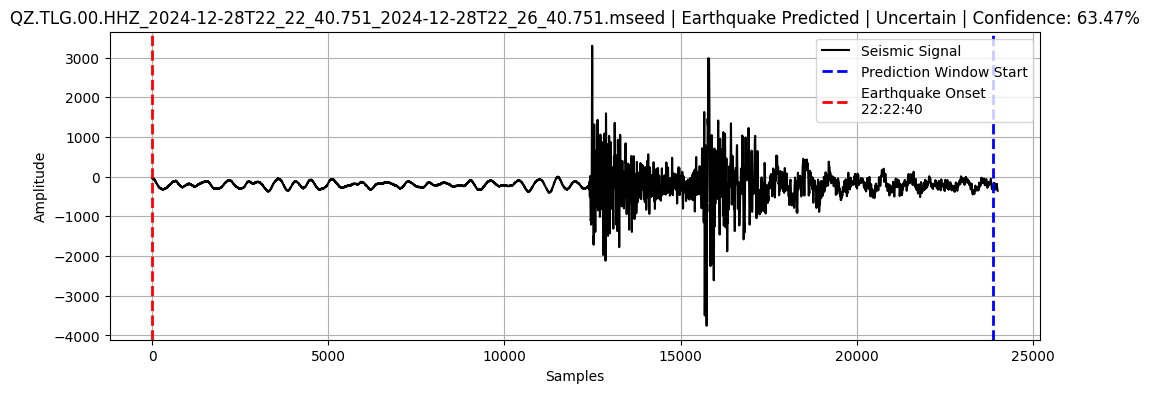

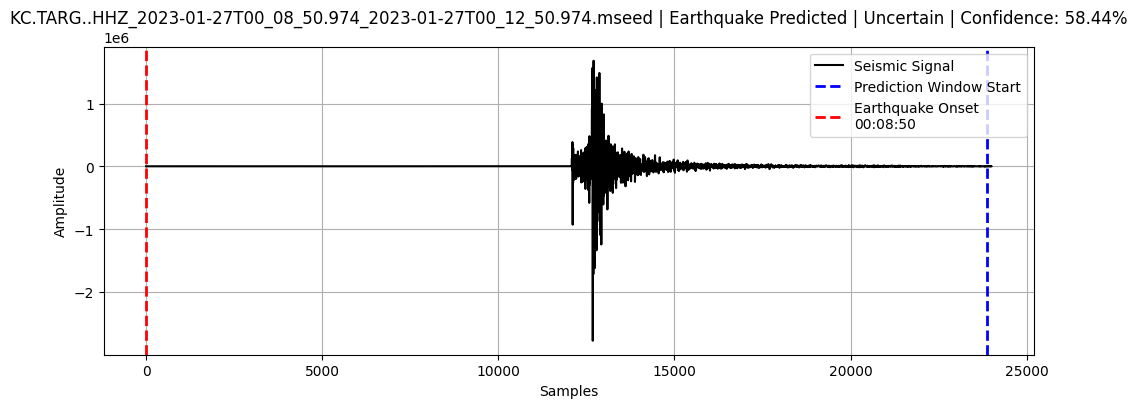

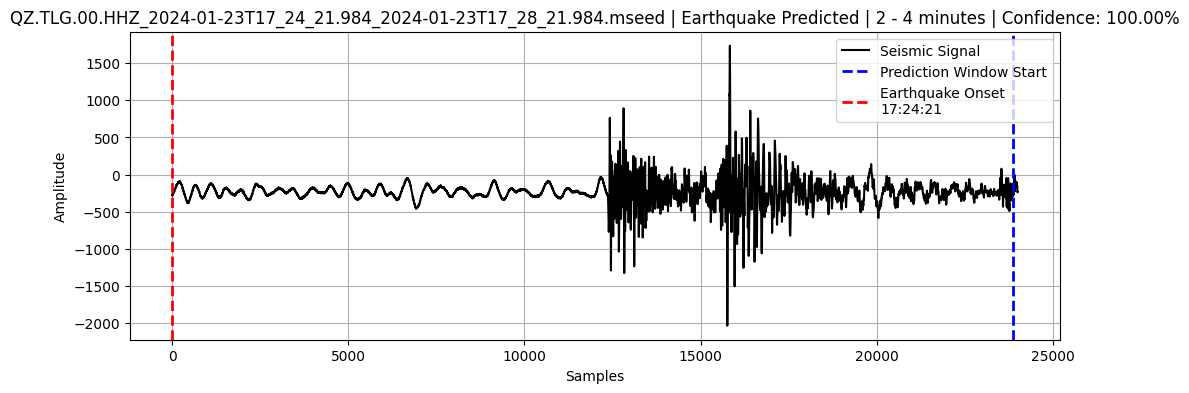


✅ All plots saved in folder: quake_charts


In [ ]:
import pandas as pd
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from obspy import read
from datetime import timedelta
import os

# 📂 Save directory for charts
save_dir = "quake_charts"
os.makedirs(save_dir, exist_ok=True)

# ✅ MSEED files
all_mseed_files = [
    "/content/drive/MyDrive/Data/test/QZ.TLG.00.HHZ_2024-11-27T20_30_26.627_2024-11-27T20_34_26.627.mseed",
    "/content/drive/MyDrive/Data/test/QZ.TLG.00.HHZ_2024-12-28T22_22_40.751_2024-12-28T22_26_40.751.mseed",
    "/content/drive/MyDrive/Data/test/KR.BAET.00.HHZ_2024-09-03T15_45_41.674_2024-09-03T15_49_41.674.mseed",
    "/content/drive/MyDrive/Data/train/QZ.TLG.00.HHZ_2024-01-23T17_24_21.984_2024-01-23T17_28_21.984.mseed",
    "/content/drive/MyDrive/Data/train/KR.JNKS.00.HHZ_2023-01-27T00_09_09.182_2023-01-27T00_13_09.182.mseed",
    "/content/drive/MyDrive/Data/train/QZ.TLG.00.HHZ_2024-01-23T12_08_07.804_2024-01-23T12_12_07.804.mseed",
    "/content/drive/MyDrive/Data/train/KC.TARG..HHZ_2023-01-27T00_08_50.974_2023-01-27T00_12_50.974.mseed",
    "/content/drive/MyDrive/Data/test/QZ.TLG.00.HHZ_2024-05-06T04_11_23.790_2024-05-06T04_15_23.790.mseed",
    "/content/drive/MyDrive/Data/test/QZ.TLG.00.HHZ_2024-08-21T21_13_14.312_2024-08-21T21_17_14.312.mseed",
    "/content/drive/MyDrive/Data/train/KR.ARLS.00.HHZ_2024-01-31T19_20_19.632_2024-01-31T19_24_19.632.mseed",
]

# ✅ pick 10 random files
sample_files = random.sample(all_mseed_files, 10)

# ✅ Prediction horizon mapping
def prediction_range(conf):
    if conf >= 0.95:
        return "2 - 4 minutes"
    elif conf >= 0.85:
        return "4 - 6 minutes"
    elif conf >= 0.70:
        return "6 - 8 minutes"
    else:
        return "Uncertain"

# ✅ Preprocess signal
def preprocess_signal(sig, target_length=120):
    if len(sig) > target_length:
        sig = sig[-target_length:]
    else:
        sig = np.pad(sig, (0, target_length - len(sig)), 'constant')
    sig = (sig - np.mean(sig)) / (np.std(sig) + 1e-6)
    return sig

# ✅ Prediction function
def predict_quake(mseed_path, horizon_sec=120):
    st = read(mseed_path)
    tr = st[0]
    signal = tr.data.astype(np.float32)
    start_time = tr.stats.starttime

    processed_signal = preprocess_signal(signal)
    input_tensor = torch.tensor(processed_signal).unsqueeze(0).unsqueeze(0)

    with torch.no_grad():
        output = model(input_tensor.to(DEVICE))
        probs = torch.softmax(output, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_class].item()

    if pred_class == 1:
        predicted_quake_time = start_time + timedelta(seconds=horizon_sec)
        return {
            "file": mseed_path.split("/")[-1],
            "start_time": start_time,
            "pred": "Earthquake Predicted",
            "predicted_time": predicted_quake_time,
            "range": prediction_range(confidence),
            "conf": confidence,
            "signal": signal
        }
    else:
        return {
            "file": mseed_path.split("/")[-1],
            "start_time": start_time,
            "pred": "No Earthquake",
            "predicted_time": None,
            "range": "-",
            "conf": confidence,
            "signal": signal
        }

# ✅ Run predictions
results = [predict_quake(f) for f in sample_files]

# ✅ Save plots for predicted earthquakes
for r in results:
    if r["pred"] == "Earthquake Predicted":
        plt.figure(figsize=(12, 4))
        plt.plot(r["signal"], color="black", label="Seismic Signal")

        # Prediction window start
        plt.axvline(x=len(r["signal"]) - 120, color="blue", linestyle="--", linewidth=2, label="Prediction Window Start")

        # Earthquake onset (start_time)
        plt.axvline(x=0, color="red", linestyle="--", linewidth=2, label=f"Earthquake Onset\n{r['start_time'].strftime('%H:%M:%S')}")

        title = f"{r['file']} | {r['pred']} | {r['range']} | Confidence: {r['conf']*100:.2f}%"
        plt.title(title, fontsize=12)
        plt.xlabel("Samples")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)

        save_path = os.path.join(save_dir, f"{r['file'].replace('.mseed','')}_quake.png")
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()

print(f"\n✅ All plots saved in folder: {save_dir}")


In [ ]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
from obspy import read
from datetime import timedelta
import os
import glob

# 📂 Save directory for charts
save_dir = "quake_charts"
os.makedirs(save_dir, exist_ok=True)

# 📂 Get all mseed files inside "train"
train_dir = "/content/drive/MyDrive/Data/train"
all_mseed_files = glob.glob(os.path.join(train_dir, "*.mseed"))

print(f"Found {len(all_mseed_files)} files in train folder")

# ✅ Prediction horizon mapping
def prediction_range(conf):
    if conf >= 0.95:
        return "2 - 4 minutes"
    elif conf >= 0.85:
        return "4 - 6 minutes"
    elif conf >= 0.70:
        return "6 - 8 minutes"
    else:
        return "Uncertain"

# ✅ Preprocess signal
def preprocess_signal(sig, target_length=120):
    if len(sig) > target_length:
        sig = sig[-target_length:]
    else:
        sig = np.pad(sig, (0, target_length - len(sig)), 'constant')
    sig = (sig - np.mean(sig)) / (np.std(sig) + 1e-6)
    return sig

# ✅ Prediction function
def predict_quake(mseed_path, horizon_sec=120):
    st = read(mseed_path)
    tr = st[0]
    signal = tr.data.astype(np.float32)
    start_time = tr.stats.starttime

    processed_signal = preprocess_signal(signal)
    input_tensor = torch.tensor(processed_signal).unsqueeze(0).unsqueeze(0)

    with torch.no_grad():
        output = model(input_tensor.to(DEVICE))
        probs = torch.softmax(output, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_class].item()

    if pred_class == 1:
        predicted_quake_time = start_time + timedelta(seconds=horizon_sec)
        return {
            "file": mseed_path.split("/")[-1],
            "start_time": start_time,
            "pred": "Earthquake Predicted",
            "predicted_time": predicted_quake_time,
            "range": prediction_range(confidence),
            "conf": confidence,
            "signal": signal
        }
    else:
        return {
            "file": mseed_path.split("/")[-1],
            "start_time": start_time,
            "pred": "No Earthquake",
            "predicted_time": None,
            "range": "-",
            "conf": confidence,
            "signal": signal
        }

# ✅ Run predictions on ALL files in train
results = [predict_quake(f) for f in all_mseed_files]

# ✅ Create DataFrame report
df_results = pd.DataFrame([
    {
        "File": r["file"],
        "Start Time": r["start_time"].strftime("%Y-%m-%d %H:%M:%S"),
        "Prediction": r["pred"],
        "Predicted EQ Time": r["predicted_time"].strftime("%Y-%m-%d %H:%M:%S") if r["predicted_time"] else "-",
        "Prediction Range": r["range"],
        "Confidence": f"{r['conf']*100:.2f}%"
    }
    for r in results
])

# ✅ Save Excel & CSV report
df_results.to_excel("quake_predictions_report.xlsx", index=False)
df_results.to_csv("quake_predictions_report.csv", index=False)

print("\n📊 Earthquake Prediction Report:")
print(df_results)
print("\n✅ Report saved as quake_predictions_report.xlsx & quake_predictions_report.csv")

# ✅ Save plots for predicted earthquakes
for r in results:
    if r["pred"] == "Earthquake Predicted":
        plt.figure(figsize=(12, 4))
        plt.plot(r["signal"], color="black", label="Seismic Signal")

        # Prediction window start
        plt.axvline(x=len(r["signal"]) - 120, color="blue", linestyle="--", linewidth=2, label="Prediction Window Start")

        # Earthquake onset (start_time)
        plt.axvline(x=0, color="red", linestyle="--", linewidth=2, label=f"Earthquake Onset\n{r['start_time'].strftime('%H:%M:%S')}")

        title = f"{r['file']} | {r['pred']} | {r['range']} | Confidence: {r['conf']*100:.2f}%"
        plt.title(title, fontsize=12)
        plt.xlabel("Samples")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)

        save_path = os.path.join(save_dir, f"{r['file'].replace('.mseed','')}_quake.png")
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close()

print(f"\n✅ Processed {len(all_mseed_files)} files from train folder")
print(f"✅ All plots saved in folder: {save_dir}")


Found 935 files in train folder

📊 Earthquake Prediction Report:
                                                  File           Start Time  \
0    KC.TARG..HHZ_2024-01-28T09_50_29.367_2024-01-2...  2024-01-28 09:50:29   
1    KC.TARG..HHZ_2024-01-26T10_15_04.640_2024-01-2...  2024-01-26 10:15:04   
2    KC.TARG..HHZ_2024-02-18T08_57_33.029_2024-02-1...  2024-02-18 08:57:33   
3    KC.TARG..HHZ_2024-02-26T12_27_00.181_2024-02-2...  2024-02-26 12:27:00   
4    KC.TARG..HHZ_2024-02-03T08_34_44.734_2024-02-0...  2024-02-03 08:34:44   
..                                                 ...                  ...   
930  QZ.SHLS.00.HHZ_2023-05-31T07_11_43.571_2023-05...  2023-05-31 07:11:43   
931  QZ.SHLS.00.HHZ_2024-01-23T10_04_33.563_2024-01...  2024-01-23 10:04:33   
932  QZ.SHLS.00.HHZ_2024-01-23T14_07_29.467_2024-01...  2024-01-23 14:07:29   
933  QZ.SHLS.00.HHZ_2024-01-22T21_11_19.742_2024-01...  2024-01-22 21:11:19   
934  KC.TARG..HHZ_2023-02-02T02_06_44.210_2023-02-0...  2023-02-02

In [ ]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
from obspy import read
from datetime import timedelta
import os
import glob

# 📂 Save directory for charts
save_dir = "quake_charts"
os.makedirs(save_dir, exist_ok=True)

# 📂 Get all mseed files inside "train"
train_dir = "/content/drive/MyDrive/Data/train"
all_mseed_files = glob.glob(os.path.join(train_dir, "*.mseed"))

print(f"Found {len(all_mseed_files)} files in train folder")

# ✅ Prediction horizon mapping
def prediction_range(conf):
    if conf >= 0.95:
        return "2 - 4 minutes"
    elif conf >= 0.85:
        return "4 - 6 minutes"
    elif conf >= 0.70:
        return "6 - 8 minutes"
    else:
        return "Uncertain"

# ✅ Preprocess signal
def preprocess_signal(sig, target_length=120):
    if len(sig) > target_length:
        sig = sig[-target_length:]
    else:
        sig = np.pad(sig, (0, target_length - len(sig)), 'constant')
    sig = (sig - np.mean(sig)) / (np.std(sig) + 1e-6)
    return sig

# ✅ Prediction function
def predict_quake(mseed_path, horizon_sec=120):
    st = read(mseed_path)
    tr = st[0]
    signal = tr.data.astype(np.float32)
    start_time = tr.stats.starttime

    processed_signal = preprocess_signal(signal)
    input_tensor = torch.tensor(processed_signal).unsqueeze(0).unsqueeze(0)

    with torch.no_grad():
        output = model(input_tensor.to(DEVICE))
        probs = torch.softmax(output, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_class].item()

    if pred_class == 1:
        predicted_quake_time = start_time + timedelta(seconds=horizon_sec)
        return {
            "file": mseed_path.split("/")[-1],
            "start_time": start_time,
            "pred": "Earthquake Predicted",
            "predicted_time": predicted_quake_time,
            "range": prediction_range(confidence),
            "conf": confidence,
            "signal": signal
        }
    else:
        return {
            "file": mseed_path.split("/")[-1],
            "start_time": start_time,
            "pred": "No Earthquake",
            "predicted_time": None,
            "range": "-",
            "conf": confidence,
            "signal": signal
        }

# ✅ Run predictions on ALL files in train
results = [predict_quake(f) for f in all_mseed_files]

# ✅ Create DataFrame report
df_results = pd.DataFrame([
    {
        "File": r["file"],
        "Start Time": r["start_time"].strftime("%Y-%m-%d %H:%M:%S"),
        "Prediction": r["pred"],
        "Predicted EQ Time": r["predicted_time"].strftime("%Y-%m-%d %H:%M:%S") if r["predicted_time"] else "-",
        "Prediction Range": r["range"],
        "Confidence": f"{r['conf']*100:.2f}%"
    }
    for r in results
])

# ✅ Save Excel & CSV report
df_results.to_excel("quake_predictions_report.xlsx", index=False)
df_results.to_csv("quake_predictions_report.csv", index=False)

print("\n📊 Earthquake Prediction Report:")
print(df_results)
print("\n✅ Report saved as quake_predictions_report.xlsx & quake_predictions_report.csv")

# ✅ Save plots for ALL predictions
for r in results:
    plt.figure(figsize=(12, 4))
    plt.plot(r["signal"], color="black", label="Seismic Signal")

    if r["pred"] == "Earthquake Predicted":
        # Prediction window start
        plt.axvline(x=len(r["signal"]) - 120, color="blue", linestyle="--", linewidth=2, label="Prediction Window Start")
        # Earthquake onset
        plt.axvline(x=0, color="red", linestyle="--", linewidth=2, label=f"Earthquake Onset\n{r['start_time'].strftime('%H:%M:%S')}")

    title = f"{r['file']} | {r['pred']} | {r['range']} | Confidence: {r['conf']*100:.2f}%"
    plt.title(title, fontsize=12)
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)

    save_path = os.path.join(save_dir, f"{r['file'].replace('.mseed','')}_result.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()

print(f"\n✅ Plots saved for ALL predictions in folder: {save_dir}")


Found 935 files in train folder

📊 Earthquake Prediction Report:
                                                  File           Start Time  \
0    KC.TARG..HHZ_2024-01-28T09_50_29.367_2024-01-2...  2024-01-28 09:50:29   
1    KC.TARG..HHZ_2024-01-26T10_15_04.640_2024-01-2...  2024-01-26 10:15:04   
2    KC.TARG..HHZ_2024-02-18T08_57_33.029_2024-02-1...  2024-02-18 08:57:33   
3    KC.TARG..HHZ_2024-02-26T12_27_00.181_2024-02-2...  2024-02-26 12:27:00   
4    KC.TARG..HHZ_2024-02-03T08_34_44.734_2024-02-0...  2024-02-03 08:34:44   
..                                                 ...                  ...   
930  QZ.SHLS.00.HHZ_2023-05-31T07_11_43.571_2023-05...  2023-05-31 07:11:43   
931  QZ.SHLS.00.HHZ_2024-01-23T10_04_33.563_2024-01...  2024-01-23 10:04:33   
932  QZ.SHLS.00.HHZ_2024-01-23T14_07_29.467_2024-01...  2024-01-23 14:07:29   
933  QZ.SHLS.00.HHZ_2024-01-22T21_11_19.742_2024-01...  2024-01-22 21:11:19   
934  KC.TARG..HHZ_2023-02-02T02_06_44.210_2023-02-0...  2023-02-02

In [ ]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
from obspy import read
from datetime import timedelta
import os
import glob
from scipy.stats import skew, kurtosis
from scipy.signal import welch
from math import log2

# 📂 Save directory for charts
save_dir = "quake_results_charts"
os.makedirs(save_dir, exist_ok=True)

# 📂 Get all mseed files inside "train"
train_dir = "/content/drive/MyDrive/Data/train"
all_mseed_files = glob.glob(os.path.join(train_dir, "*.mseed"))

print(f"Found {len(all_mseed_files)} files in train folder")

# ✅ Prediction horizon mapping
def prediction_range(conf):
    if conf >= 0.95:
        return "2 - 4 minutes"
    elif conf >= 0.85:
        return "4 - 6 minutes"
    elif conf >= 0.70:
        return "6 - 8 minutes"
    else:
        return "Uncertain"

# ✅ Preprocess signal
def preprocess_signal(sig, target_length=120):
    if len(sig) > target_length:
        sig = sig[-target_length:]
    else:
        sig = np.pad(sig, (0, target_length - len(sig)), 'constant')
    sig = (sig - np.mean(sig)) / (np.std(sig) + 1e-6)
    return sig

# ✅ Compute advanced features
def compute_features(signal, fs=100):
    # Basic
    sig_mean = float(np.mean(signal))
    sig_std = float(np.std(signal))
    sig_max = float(np.max(signal))
    sig_min = float(np.min(signal))
    sig_len = len(signal)
    peak2peak = sig_max - sig_min

    # Energy
    energy = float(np.sum(signal**2))
    rms = float(np.sqrt(np.mean(signal**2)))

    # Shape
    sig_skew = float(skew(signal))
    sig_kurt = float(kurtosis(signal))

    # Frequency domain
    freqs, psd = welch(signal, fs=fs)
    dominant_freq = float(freqs[np.argmax(psd)])

    # Spectral Entropy
    psd_norm = psd / np.sum(psd)
    spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-12))

    return {
        "Signal Length": sig_len,
        "Signal Mean": sig_mean,
        "Signal Std": sig_std,
        "Signal Max": sig_max,
        "Signal Min": sig_min,
        "Peak-to-Peak": peak2peak,
        "Energy": energy,
        "RMS": rms,
        "Skewness": sig_skew,
        "Kurtosis": sig_kurt,
        "Dominant Freq": dominant_freq,
        "Spectral Entropy": spectral_entropy
    }

# ✅ Prediction function
def predict_quake(mseed_path, horizon_sec=120, fs=100):
    st = read(mseed_path)
    tr = st[0]
    signal = tr.data.astype(np.float32)
    start_time = tr.stats.starttime

    processed_signal = preprocess_signal(signal)
    input_tensor = torch.tensor(processed_signal).unsqueeze(0).unsqueeze(0)

    with torch.no_grad():
        output = model(input_tensor.to(DEVICE))
        probs = torch.softmax(output, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_class].item()

    features = compute_features(signal, fs=fs)

    if pred_class == 1:
        predicted_quake_time = start_time + timedelta(seconds=horizon_sec)
        lead_time = horizon_sec
        return {
            "File": os.path.basename(mseed_path),
            "Start Time": start_time,
            "Prediction": "Earthquake Predicted",
            "Predicted EQ Time": predicted_quake_time,
            "Prediction Range": prediction_range(confidence),
            "Confidence": confidence,
            "Lead Time (sec)": lead_time,
            **features,
            "signal": signal
        }
    else:
        return {
            "File": os.path.basename(mseed_path),
            "Start Time": start_time,
            "Prediction": "No Earthquake",
            "Predicted EQ Time": None,
            "Prediction Range": "-",
            "Confidence": confidence,
            "Lead Time (sec)": "-",
            **features,
            "signal": signal
        }

# ✅ Run predictions on ALL files in train
results = [predict_quake(f) for f in all_mseed_files]

# ✅ Create DataFrame with full details
df_results = pd.DataFrame([
    {
        "File": r["File"],
        "Start Time": r["Start Time"].strftime("%Y-%m-%d %H:%M:%S"),
        "Prediction": r["Prediction"],
        "Predicted EQ Time": r["Predicted EQ Time"].strftime("%Y-%m-%d %H:%M:%S") if r["Predicted EQ Time"] else "-",
        "Prediction Range": r["Prediction Range"],
        "Confidence": f"{r['Confidence']*100:.2f}%",
        "Lead Time (sec)": r["Lead Time (sec)"],
        "Signal Length": r["Signal Length"],
        "Signal Mean": r["Signal Mean"],
        "Signal Std": r["Signal Std"],
        "Signal Max": r["Signal Max"],
        "Signal Min": r["Signal Min"],
        "Peak-to-Peak": r["Peak-to-Peak"],
        "Energy": r["Energy"],
        "RMS": r["RMS"],
        "Skewness": r["Skewness"],
        "Kurtosis": r["Kurtosis"],
        "Dominant Freq": r["Dominant Freq"],
        "Spectral Entropy": r["Spectral Entropy"]
    }
    for r in results
])

# ✅ Save Excel & CSV report with all details
df_results.to_excel("quake_predictions_full_detailed.xlsx", index=False)
df_results.to_csv("quake_predictions_full_detailed.csv", index=False)

print("\n📊 Full Detailed Earthquake Prediction Report:")
print(df_results.head())
print("\n✅ Report saved as quake_predictions_full_detailed.xlsx & quake_predictions_full_detailed.csv")


Found 935 files in train folder

📊 Full Detailed Earthquake Prediction Report:
                                                File           Start Time  \
0  KC.TARG..HHZ_2024-01-28T09_50_29.367_2024-01-2...  2024-01-28 09:50:29   
1  KC.TARG..HHZ_2024-01-26T10_15_04.640_2024-01-2...  2024-01-26 10:15:04   
2  KC.TARG..HHZ_2024-02-18T08_57_33.029_2024-02-1...  2024-02-18 08:57:33   
3  KC.TARG..HHZ_2024-02-26T12_27_00.181_2024-02-2...  2024-02-26 12:27:00   
4  KC.TARG..HHZ_2024-02-03T08_34_44.734_2024-02-0...  2024-02-03 08:34:44   

             Prediction    Predicted EQ Time Prediction Range Confidence  \
0         No Earthquake                    -                -     88.37%   
1  Earthquake Predicted  2024-01-26 10:17:04    2 - 4 minutes    100.00%   
2  Earthquake Predicted  2024-02-18 08:59:33    6 - 8 minutes     70.58%   
3         No Earthquake                    -                -     79.13%   
4         No Earthquake                    -                -     89.01%   

 